# TT-PINN de CO - evaluación interpolativa final R1F_STD

**Versión:** `TT_PINN_CO_INTERP_FINAL_R1F_STD`  
**Propósito:** entrenar y evaluar una única TT-PINN derivada de la PINN
densa R5F_STD, sustituyendo solo las matrices entre capas
ocultas por núcleos Tensor-Train.  
**Alcance:** prueba de compresión estructural uno-a-uno para
`CO`; no realiza optimización, ranking, selección de rango por
desempeño ni reentrenamiento posterior a TEST.  
**Entradas principales:** PROTOCOL R1, configuración/seed/épocas FROZEN y
checkpoint denso `R5F_STD`.  
**Salidas principales:** contrato TT, checkpoint TT, auditorías de TEST,
métricas pareadas, figuras, perfil homogéneo de almacenamiento y manifiesto.  
**Entorno previsto:** Python 3, PyTorch; ejecución local o Google Colab.  
**Estado de esta fuente:** `FINAL / SOURCE / TT-TEST CLOSED / READY FOR EXECUTION`.

> TEST ya fue evaluado por el baseline denso histórico. En este experimento
> se garantiza una única materialización dentro de la ejecución TT, siempre
> después de congelar, serializar, recargar y firmar el modelo comprimido.

## SEC-00 - Mapa del notebook y contrato experimental

| Sección | Finalidad |
|---|---|
| SEC-00 | propósito, alcance, mapa e hipótesis |
| SEC-01 | entorno, rutas, determinismo y ledger TT |
| SEC-02 | autenticación de PROTOCOL, OPT y baseline densa |
| SEC-03 | contrato TT congelado por geometría y almacenamiento |
| SEC-04 | implementación de contracción TT directa |
| SEC-05 | pruebas unitarias y de gradientes de `TTLinear` |
| SEC-06 | DEV, preprocesamiento y núcleo científico heredado |
| SEC-07 | entrenamiento único con todo DEV |
| SEC-08 | congelamiento y puerta criptográfica pre-TEST |
| SEC-09 | apertura única de TEST en la ejecución TT |
| SEC-10 | evaluación pareada y no inferioridad informativa |
| SEC-11 | figuras, almacenamiento, memoria y latencia homogénea |
| SEC-12 | reporte, hashes, manifiesto y cierre |

### Contratos predeclarados

- Se conservan macroarquitectura, activación, dropout, transformación,
  pérdida, física, optimizador, seed y épocas del campeón denso.
- Entrada, salida y sesgos permanecen densos; solo se tensorizan matrices
  entre capas ocultas.
- El rango uniforme es el mayor que reduce al menos 75 % tanto los
  parámetros como el `state_dict` estimado, sin consultar métricas.
- Márgenes de ingeniería: caída de R2 <= 0,02; RMSE y MAE <= 1,10 veces el
  baseline; caída de PCD <= 1 punto porcentual; reducción del `state_dict`
  >= 75 %. Estos valores no proceden del artículo TT-PINN ni de una norma
  PEMS; quedan congelados antes de entrenar.


## SEC-01 - Entorno, rutas, determinismo y ledger TT


### C-01.01 - Dependencias y raíz reproducible

**Finalidad:** resolver el entorno sin rutas personales embebidas.
**Entradas:** raíz actual o variable `PEMS_TT_PINN_PROJECT_ROOT`.
**Salidas:** `PROJECT_ROOT_PATH` y dependencias verificadas.
**Control y parada:** se detiene si la raíz no es única o faltan marcadores.


In [1]:
# [C-01.01] Dependencias y descubrimiento reproducible de la raíz
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "psutil": "psutil",
    "sklearn": "scikit-learn",
    "torch": "torch",
}
missing_packages = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

google_available = importlib.util.find_spec("google") is not None
in_colab = (
    google_available
    and importlib.util.find_spec("google.colab") is not None
)
if in_colab:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

def root_has_project_markers(candidate: Path) -> bool:
    return (
        (candidate / "standards" / "Manual Estilo Convenciones Notebooks - R4.md").is_file()
        and (candidate / "data" / "raw" / "gt_2011.csv").is_file()
    )

configured_root = os.environ.get("PEMS_TT_PINN_PROJECT_ROOT", "").strip()
if configured_root:
    project_root_path = Path(configured_root).expanduser()
else:
    current = Path.cwd().resolve()
    local_candidates = [current, *current.parents]
    local_match = next(
        (item for item in local_candidates if root_has_project_markers(item)),
        None,
    )
    if local_match is not None:
        project_root_path = local_match
    elif in_colab:
        drive_root = Path("/content/drive/MyDrive")
        matches = list(drive_root.glob("**/data/raw/gt_2011.csv"))
        valid_roots = [item.parents[2] for item in matches]
        valid_roots = [item for item in valid_roots if root_has_project_markers(item)]
        if len(valid_roots) != 1:
            raise FileNotFoundError(
                "Defina PEMS_TT_PINN_PROJECT_ROOT; la raíz no es inequívoca."
            )
        project_root_path = valid_roots[0]
    else:
        raise FileNotFoundError(
            "Defina PEMS_TT_PINN_PROJECT_ROOT con la raíz absoluta del proyecto."
        )

PROJECT_ROOT_PATH = str(project_root_path.resolve())
print(
    {
        "entorno": "Google Colab" if in_colab else "local",
        "raíz_detectada": PROJECT_ROOT_PATH,
        "paquetes_instalados": missing_packages,
    }
)


{'entorno': 'local', 'raíz_detectada': 'C:\\ChatGPT-Work\\Walk_Forward R8', 'paquetes_instalados': []}


### C-01.02 - Constantes y rutas congeladas

**Finalidad:** declarar identidad, física, presupuestos TT y márgenes.
**Entradas:** contrato metodológico R1F_STD.
**Salidas:** constantes y `FinalPaths`.
**Control y parada:** ningún valor depende de métricas de TEST.


In [2]:
# [C-01.02] Constantes científicas, rutas y criterios congelados
import contextlib
import copy
import hashlib
import importlib.metadata
import io
import json
import math
import os
import platform
import random
import shutil
import tempfile
import time
import uuid
from collections import OrderedDict
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from typing import Any, Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

VERSION = "TT_PINN_CO_INTERP_FINAL_R1F_STD"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
OPT_VERSION = "CO_INTERP_OPT_R5"
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_OPT - R5.ipynb"
DENSE_FINAL_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_STD.ipynb"
CURRENT_NOTEBOOK_NAME = "05_TT_PINN_CO_INTERP_FINAL - R1F_STD.ipynb"

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "CO"
TARGET_DISPLAY = "CO"
PHYSICS_MODE = "CDP_NEG"
PHYSICS_FEATURE = "CDP"
EXPECTED_DERIVATIVE_SIGN = "<= 0"
MONOTONIC_CONSTRAINT = "dCO_dCDP_le_0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
PCD_REFERENCE_THRESHOLD_PCT = 95.0
YEARS = [2011, 2012, 2013, 2014, 2015]
PHYSICS_EVAL_ROWS = 2048
EPS_DIMENSIONLESS = 1e-6
MAX_TRAINABLE_PARAMETERS = 500_000
TF32 = True

TT_ORDER = 3
MAX_TT_PARAMETER_FRACTION = 0.25
MAX_TT_STATE_DICT_FRACTION = 0.25
MAX_TT_RANK_CANDIDATE = 64
TT_FORWARD_RECONSTRUCTS_DENSE = False
NON_INFERIORITY_CONTRACT = {
    "max_r2_drop": 0.02,
    "max_rmse_ratio": 1.10,
    "max_mae_ratio": 1.10,
    "max_pcd_drop_pp": 1.0,
    "min_state_dict_reduction_fraction": 0.75,
    "origin": "PREDECLARED_ENGINEERING_R1_NOT_FROM_PAPER_OR_PEMS_NORM",
}

LATENCY_WARMUP = 20
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 5
THROUGHPUT_REPETITIONS = 30
PDP_POINTS = 120
CANONICAL_FIGURE_COUNT = 13
SUPPLEMENTAL_FIGURE_COUNT = 2
FIGURE_FORMATS = ("png", "svg")

PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OPT_REL = Path("models") / "interp" / "work_pinn_co_interp_opt_r5"
DENSE_FINAL_REL = Path("models") / "interp" / "work_pinn_co_interp_final_r5f_std"
OUTPUT_REL = Path("models") / "interp" / "work_tt_pinn_co_interp_final_r1f_std"

ARTIFACT_TOKEN = "CO_TT_R1F_STD"
DENSE_ARTIFACT_TOKEN = "CO_R5F_STD"
PRE_TEST_GATE_FILENAME = f"PRE_TEST_GATE_{ARTIFACT_TOKEN}.json"
TEST_LEDGER_FILENAME = f"TEST_ACCESS_LEDGER_{ARTIFACT_TOKEN}.json"

@dataclass(frozen=True)
class FinalPaths:
    root: Path
    work: Path
    audit: Path
    configs: Path
    tables: Path
    figures: Path
    model: Path
    reports: Path

def make_paths(root: Path) -> FinalPaths:
    work = root / OUTPUT_REL
    paths = FinalPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        tables=work / "tables",
        figures=work / "figures",
        model=work / "model",
        reports=work / "reports",
    )
    for key, value in asdict(paths).items():
        if key != "root":
            Path(value).mkdir(parents=True, exist_ok=True)
    return paths


### C-01.03 - Utilidades reproducibles

**Finalidad:** centralizar hashes, atomicidad, seed y entorno.
**Entradas:** rutas, objetos y dispositivo.
**Salidas:** funciones puras y manifiesto de entorno.
**Control y parada:** toda persistencia se hace de forma atómica.


In [3]:
# [C-01.03] Hashes, escritura atómica, semilla y entorno
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def canonical_json(value: Any) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))

def config_hash(config: dict) -> str:
    payload = {
        key: value for key, value in config.items() if key != "config_hash"
    }
    return sha256_bytes(canonical_json(payload).encode("utf-8"))

def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        temporary_path.write_text(text, encoding="utf-8", newline="\n")
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()

def atomic_json(path: Path, value: Any) -> None:
    atomic_text(
        path,
        json.dumps(
            value,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
            default=str,
        )
        + "\n",
    )

def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))

def serialized_torch_bytes(value: Any) -> int:
    buffer = io.BytesIO()
    torch.save(value, buffer)
    return len(buffer.getvalue())

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

def select_device() -> torch.device:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = TF32
        torch.backends.cudnn.allow_tf32 = TF32
    return device

def environment_manifest(device: torch.device) -> dict:
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": importlib.metadata.version("scikit-learn"),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "tf32": TF32,
        "deterministic_algorithms": "warn_only",
    }


### C-01.04 - Inicialización single-shot

**Finalidad:** crear una salida limpia y un ledger TT persistente.
**Entradas:** raíz validada y rutas upstream.
**Salidas:** `PATHS`, `DEVICE`, entorno y ledger cerrado.
**Control y parada:** se detiene ante una salida TT previa no vacía.


In [4]:
# [C-01.04] Inicialización single-shot y ledger de TEST de la ejecución TT
def validate_project_root(project_root_path: str | Path) -> Path:
    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [
        root / "notebooks" / PROTOCOL_NOTEBOOK_NAME,
        root / "notebooks" / OPT_NOTEBOOK_NAME,
        root / "notebooks" / DENSE_FINAL_NOTEBOOK_NAME,
        root / PROTOCOL_REL,
        root / OPT_REL,
        root / DENSE_FINAL_REL,
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "La raíz no contiene la cadena requerida:\n- "
            + "\n- ".join(missing)
        )
    return root

PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
output_candidate = PROJECT_ROOT / OUTPUT_REL
if output_candidate.exists() and any(output_candidate.rglob("*")):
    raise RuntimeError(
        "Salida TT previa detectada. Preserve la evidencia y use un "
        "directorio limpio para una nueva ejecución single-shot."
    )
PATHS = make_paths(PROJECT_ROOT)
DEVICE = select_device()
ENVIRONMENT = environment_manifest(DEVICE)
TEST_LEDGER_PATH = PATHS.audit / TEST_LEDGER_FILENAME
TEST_LEDGER = {
    "schema_version": "TT_R1F_STD_TEST_LEDGER_V1",
    "version": VERSION,
    "execution_id": str(uuid.uuid4()),
    "revision": 1,
    "state": "TT_TEST_CLOSED_PRE_TRAINING",
    "created_at_utc": utc_now(),
    "updated_at_utc": utc_now(),
    "access_count": 0,
    "target_rows_materialized": 0,
    "global_test_previously_used_by_dense_baseline": True,
}
atomic_json(TEST_LEDGER_PATH, TEST_LEDGER)
_TEST_HAS_BEEN_OPENED = False

def update_test_ledger(state: str, **fields: Any) -> dict:
    global TEST_LEDGER
    current = read_json(TEST_LEDGER_PATH)
    if current.get("execution_id") != TEST_LEDGER["execution_id"]:
        raise RuntimeError("TEST_LEDGER_EXECUTION_MISMATCH")
    current.update(fields)
    current["state"] = state
    current["revision"] = int(current.get("revision", 0)) + 1
    current["updated_at_utc"] = utc_now()
    atomic_json(TEST_LEDGER_PATH, current)
    TEST_LEDGER = current
    return copy.deepcopy(current)

def assert_test_closed(context: str) -> None:
    ledger = read_json(TEST_LEDGER_PATH)
    if _TEST_HAS_BEEN_OPENED or int(ledger.get("access_count", 0)) != 0:
        raise RuntimeError(f"TT_TEST_OPEN_DURING_{context}")
    allowed = {
        "TT_TEST_CLOSED_PRE_TRAINING",
        "TT_MODEL_FROZEN_PRE_TEST",
    }
    if ledger.get("state") not in allowed:
        raise RuntimeError(f"TT_TEST_LEDGER_STATE_INVALID_DURING_{context}")

atomic_json(
    PATHS.audit / f"ENVIRONMENT_{ARTIFACT_TOKEN}.json",
    ENVIRONMENT,
)
display(
    pd.Series(
        {
            "versión": VERSION,
            "dispositivo": str(DEVICE),
            "raíz": str(PROJECT_ROOT),
            "baseline densa": str(PROJECT_ROOT / DENSE_FINAL_REL),
            "salida TT": str(PATHS.work),
            "política": "ONE_TT_MODEL_ONE_LOCAL_TEST_MATERIALIZATION",
            "ledger": TEST_LEDGER["state"],
        },
        name="valor",
    ).to_frame()
)


,valor
versión,TT_PINN_CO_INTERP_FINAL_R1F_STD
dispositivo,cuda
raíz,C:\ChatGPT-Work\Walk_Forward R8
baseline densa,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
salida TT,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
política,ONE_TT_MODEL_ONE_LOCAL_TEST_MATERIALIZATION
ledger,TT_TEST_CLOSED_PRE_TRAINING


## SEC-02 - Autenticación de la derivación upstream


### C-02.01 - Verificación PROTOCOL, OPT y baseline densa

**Finalidad:** autenticar la cadena sin atribuir al TT un handoff directo falso.
**Entradas:** manifiestos, configuración, checkpoint y tablas densas.
**Salidas:** `FROZEN`, configuración, seed y épocas heredadas.
**Control y parada:** no lee contenido de métricas/predicciones antes del freeze TT.


In [5]:
# [C-02.01] Autenticación PROTOCOL, OPT y baseline densa completa
def resolve_protocol_data_sources(root: Path, split: dict) -> dict[int, Path]:
    records = split.get("data_hashes", [])
    if len(records) != len(YEARS):
        raise RuntimeError("PROTOCOL no declara exactamente cinco fuentes")
    sources = {}
    for record in records:
        year = int(record["year"])
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if year not in YEARS or year in sources or relative != expected:
            raise RuntimeError(f"Fuente no canónica o duplicada para {year}")
        path = (root / relative).resolve()
        if not path.is_file() or sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Fuente ausente o hash distinto para {year}")
        sources[year] = path
    return sources

def verify_upstream_derivation(root: Path, paths: FinalPaths) -> dict:
    protocol = root / PROTOCOL_REL
    opt = root / OPT_REL
    dense = root / DENSE_FINAL_REL
    artifacts = {
        "assignment": protocol / "tables" / "INTERP_ROW_ASSIGNMENT.csv",
        "split": protocol / "manifests" / "INTERP_SPLIT_MANIFEST.json",
        "folds": protocol / "manifests" / "INTERP_FOLDS_MANIFEST.json",
        "domain": protocol / "manifests" / "INTERP_DOMAIN_ENVELOPE.json",
        "protocol_manifest": (
            protocol
            / "manifests"
            / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "best_config": opt / "configs" / "BEST_CONFIG_CO_INTERP_R5.json",
        "training_policy": (
            opt / "configs" / "FINAL_TRAINING_POLICY_CO_INTERP_R5.json"
        ),
        "representative_seed": (
            opt / "configs" / "FINAL_REPRESENTATIVE_SEED_CO_R5.json"
        ),
        "frozen_opt": (
            opt / "configs" / "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json"
        ),
        "dense_manifest": (
            dense / "configs" / "FINAL_MODEL_MANIFEST_CO_R5F_STD.json"
        ),
        "dense_metrics": dense / "tables" / "FINAL_METRICS_CO_R5F_STD.csv",
        "dense_physics": dense / "tables" / "PHYSICS_AUDIT_CO_R5F_STD.csv",
        "dense_dev_predictions": (
            dense / "tables" / "DEV_PREDICTIONS_CO_R5F_STD.csv"
        ),
        "dense_test_predictions": (
            dense / "tables" / "TEST_PREDICTIONS_CO_R5F_STD.csv"
        ),
        "dense_profile": (
            dense / "configs" / "MODEL_PROFILE_CO_PINN_INTERP_R5.json"
        ),
    }
    missing = [str(path) for path in artifacts.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(
            "Artefactos upstream ausentes:\n- " + "\n- ".join(missing)
        )

    split = read_json(artifacts["split"])
    folds = read_json(artifacts["folds"])
    domain = read_json(artifacts["domain"])
    protocol_manifest = read_json(artifacts["protocol_manifest"])
    config = read_json(artifacts["best_config"])
    policy = read_json(artifacts["training_policy"])
    seed_contract = read_json(artifacts["representative_seed"])
    frozen_opt = read_json(artifacts["frozen_opt"])
    dense_manifest = read_json(artifacts["dense_manifest"])

    for name, manifest in {
        "split": split,
        "folds": folds,
        "domain": domain,
        "protocol_manifest": protocol_manifest,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"{name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"{name} declara otro protocolo")

    protocol_records = {
        str(record["path"]).replace("\\", "/"): record
        for record in protocol_manifest.get("artifacts", [])
    }
    for key in ("assignment", "split", "folds", "domain"):
        relative = str(artifacts[key].relative_to(protocol)).replace("\\", "/")
        record = protocol_records.get(relative)
        if record is None or sha256_file(artifacts[key]) != record.get("sha256"):
            raise RuntimeError(f"Artefacto PROTOCOL no autenticado: {relative}")

    assignment = pd.read_csv(artifacts["assignment"])
    required_columns = {
        "global_row_id", "year", "row_in_year", "block_id",
        "partition", "cv_role", "cv_fold",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("INTERP_ROW_ASSIGNMENT no tiene el esquema requerido")
    if assignment.global_row_id.duplicated().any():
        raise RuntimeError("global_row_id no es único")
    if set(assignment.partition.unique()) != {"DEV", "TEST"}:
        raise RuntimeError("Las particiones no son exactamente DEV y TEST")

    assignment_hash = sha256_file(artifacts["assignment"])
    if assignment_hash != split.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación inconsistente")
    fold_payload = (
        assignment.loc[
            assignment.partition.eq("DEV"),
            ["block_id", "cv_role", "cv_fold"],
        ]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != folds.get("fold_assignment_sha256"):
        raise RuntimeError("Hash de folds inconsistente")

    if config_hash(config) != config.get("config_hash"):
        raise RuntimeError("Hash semántico de BEST_CONFIG inválido")
    if config.get("target") != TARGET or config.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError("BEST_CONFIG pertenece a otro experimento")
    if config.get("row_assignment_sha256") != assignment_hash:
        raise RuntimeError("BEST_CONFIG referencia otra asignación")
    if config.get("fold_assignment_sha256") != fold_hash:
        raise RuntimeError("BEST_CONFIG referencia otros folds")

    if frozen_opt.get("status") != "FROZEN":
        raise RuntimeError("El manifiesto OPT no está FROZEN")
    if frozen_opt.get("version") != OPT_VERSION:
        raise RuntimeError("El manifiesto OPT declara otra versión")
    if frozen_opt.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("El productor OPT no coincide")
    if frozen_opt.get("authorized_direct_consumer") != DENSE_FINAL_NOTEBOOK_NAME:
        raise RuntimeError("El consumidor directo autorizado no es la PINN densa")
    if frozen_opt.get("test_opened") is not False:
        raise RuntimeError("OPT declara acceso a TEST")

    representative_seed = int(seed_contract.get("selected_seed", -1))
    final_epochs = int(policy.get("FINAL_EPOCHS", 0))
    if policy.get("status") != "FROZEN" or policy.get("test_opened") is not False:
        raise RuntimeError("La política final no está congelada antes de TEST")
    if not seed_contract.get("selected_before_test"):
        raise RuntimeError("La seed no se seleccionó antes de TEST")
    if int(config.get("final_representative_seed", -2)) != representative_seed:
        raise RuntimeError("Seed contradictoria en BEST_CONFIG")
    if not 1 <= final_epochs <= int(config["max_epochs"]):
        raise RuntimeError("FINAL_EPOCHS fuera del presupuesto")

    dense_model = dense / "model" / f"final_model_seed_{representative_seed}.pt"
    if not dense_model.is_file():
        raise FileNotFoundError(f"Checkpoint denso ausente: {dense_model}")
    dense_model_hash = sha256_file(dense_model)
    dense_checks = {
        "status": dense_manifest.get("status") == "COMPLETE",
        "producer": dense_manifest.get("producer_notebook") == DENSE_FINAL_NOTEBOOK_NAME,
        "protocol": dense_manifest.get("protocol_version") == PROTOCOL_VERSION,
        "opt": dense_manifest.get("opt_version") == OPT_VERSION,
        "config": dense_manifest.get("config_hash") == config["config_hash"],
        "assignment": dense_manifest.get("row_assignment_sha256") == assignment_hash,
        "folds": dense_manifest.get("fold_assignment_sha256") == fold_hash,
        "seed": int(dense_manifest.get("representative_seed", -1)) == representative_seed,
        "epochs": int(dense_manifest.get("final_epochs", -1)) == final_epochs,
        "single_model": int(dense_manifest.get("model_count", -1)) == 1,
        "model_hash": dense_manifest.get("model_sha256") == dense_model_hash,
        "test_once_dense": dense_manifest.get("test_opened_once") is True,
        "no_dense_retraining": dense_manifest.get("retraining_after_test") is False,
        "no_dense_change": dense_manifest.get("model_changed_after_test") is False,
    }
    if not all(dense_checks.values()):
        failed = [name for name, passed in dense_checks.items() if not passed]
        raise RuntimeError(f"Baseline densa no autenticada: {failed}")

    local_copies = {}
    for key in ("best_config", "training_policy", "representative_seed", "frozen_opt"):
        original = artifacts[key]
        destination = paths.configs / original.name
        shutil.copy2(original, destination)
        if sha256_file(destination) != sha256_file(original):
            raise RuntimeError(f"Copia byte a byte falló: {original.name}")
        local_copies[key] = destination

    protected_hashes = {
        key: sha256_file(artifacts[key])
        for key in (
            "dense_manifest", "dense_metrics", "dense_physics",
            "dense_dev_predictions", "dense_test_predictions", "dense_profile",
        )
    }
    protected_hashes["dense_model"] = dense_model_hash
    contract = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "consumer_notebook": CURRENT_NOTEBOOK_NAME,
        "consumer_role": "INDIRECT_DERIVATIVE_OF_AUTHENTICATED_DENSE_FINAL",
        "dense_direct_consumer": DENSE_FINAL_NOTEBOOK_NAME,
        "protocol_manifest_sha256": sha256_file(artifacts["protocol_manifest"]),
        "opt_frozen_manifest_sha256": sha256_file(artifacts["frozen_opt"]),
        "dense_final_manifest_sha256": protected_hashes["dense_manifest"],
        "dense_model_sha256": dense_model_hash,
        "dense_config_hash": config["config_hash"],
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "test_metrics_read_before_tt_freeze": False,
        "dense_test_already_used_historically": True,
    }
    atomic_json(
        paths.audit / f"UPSTREAM_DERIVATION_CONTRACT_{ARTIFACT_TOKEN}.json",
        contract,
    )
    return {
        "assignment": assignment,
        "split": split,
        "folds": folds,
        "domain": domain,
        "data_sources": resolve_protocol_data_sources(root, split),
        "config": config,
        "policy": policy,
        "seed_contract": seed_contract,
        "frozen_opt": frozen_opt,
        "dense_manifest": dense_manifest,
        "dense_model_path": dense_model,
        "artifact_paths": artifacts,
        "local_copies": local_copies,
        "protected_hashes_before_test": protected_hashes,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "use_lbfgs": bool(policy.get("use_lbfgs")),
    }

assert_test_closed("UPSTREAM_AUTHENTICATION")
FROZEN = verify_upstream_derivation(PROJECT_ROOT, PATHS)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = copy.deepcopy(FROZEN["config"])
FINAL_POLICY = copy.deepcopy(FROZEN["policy"])
REPRESENTATIVE_SEED = int(FROZEN["representative_seed"])
FINAL_EPOCHS = int(FROZEN["final_epochs"])
USE_LBFGS = bool(FROZEN["use_lbfgs"])
KNN_K = int(FROZEN["domain"]["knn_k"])
KNN_QUANTILE = float(FROZEN["domain"]["knn_quantile"])
DATA_SOURCES = dict(FROZEN["data_sources"])
display(
    pd.Series(
        {
            "protocolo": FROZEN["split"]["status"],
            "baseline densa": FROZEN["dense_manifest"]["status"],
            "config_hash denso": BEST_CONFIG["config_hash"],
            "seed": REPRESENTATIVE_SEED,
            "épocas": FINAL_EPOCHS,
            "filas DEV": int(ASSIGNMENT.partition.eq("DEV").sum()),
            "filas TEST solo metadatos": int(ASSIGNMENT.partition.eq("TEST").sum()),
            "métricas densas leídas": False,
        },
        name="resultado",
    ).to_frame()
)


,resultado
protocolo,FROZEN
baseline densa,COMPLETE
config_hash denso,e5d4ddb830ce31387f933b4c4522485991650de24af4ae...
seed,126
épocas,85
filas DEV,29845
filas TEST solo metadatos,6888
métricas densas leídas,False


## SEC-03 - Contrato TT predeclarado


### C-03.01 - Factorización, rango y presupuesto

**Finalidad:** fijar la representación TT por geometría y almacenamiento.
**Entradas:** anchos densos y `state_dict` autenticado.
**Salidas:** contrato TT y tabla completa de rangos elegibles.
**Control y parada:** elige el mayor rango bajo dos presupuestos, sin métricas.


In [6]:
# [C-03.01] Factorización y rango TT congelados sin métricas predictivas
def balanced_integer_factors(value: int, order: int) -> tuple[int, ...]:
    if value < 1 or order < 1:
        raise ValueError("value y order deben ser positivos")
    candidates = []

    def search(remaining: int, depth: int, minimum: int, prefix: list[int]):
        if depth == 1:
            if remaining >= minimum:
                factors = tuple([*prefix, remaining])
                ratio = factors[-1] / factors[0]
                log_spread = float(np.var(np.log(np.asarray(factors, float))))
                candidates.append((ratio, log_spread, factors))
            return
        limit = int(round(remaining ** (1 / depth))) + 1
        for factor in range(minimum, max(minimum, limit) + 1):
            if remaining % factor == 0:
                search(remaining // factor, depth - 1, factor, [*prefix, factor])

    search(value, order, 1, [])
    if not candidates:
        raise ValueError(f"No se pudo factorizar {value} en {order} modos")
    return min(candidates)[2]

def dense_parameter_count(config: dict) -> int:
    first_dim = 2 * int(config.get("fourier_dim", 0)) or len(FEATURES)
    dimensions = [first_dim, *map(int, config["hidden_widths"]), 1]
    total = sum(
        input_dim * output_dim + output_dim
        for input_dim, output_dim in zip(dimensions, dimensions[1:])
    )
    if config.get("physics_weighting") == "ADAPTIVE_LEARNED":
        total += 2
    return int(total)

def tt_linear_parameter_count(
    input_factors: Sequence[int],
    output_factors: Sequence[int],
    ranks: Sequence[int],
    include_bias: bool = True,
) -> int:
    mode_sizes = [*output_factors, *input_factors]
    if len(ranks) != len(mode_sizes) + 1:
        raise ValueError("La longitud de ranks no coincide con los modos")
    core_parameters = sum(
        int(ranks[index])
        * int(mode_sizes[index])
        * int(ranks[index + 1])
        for index in range(len(mode_sizes))
    )
    bias_parameters = int(np.prod(output_factors)) if include_bias else 0
    return int(core_parameters + bias_parameters)

def tt_model_parameter_count(config: dict, rank: int) -> int:
    widths = list(map(int, config["hidden_widths"]))
    first_dim = 2 * int(config.get("fourier_dim", 0)) or len(FEATURES)
    total = first_dim * widths[0] + widths[0]
    total += widths[-1] + 1
    if config.get("physics_weighting") == "ADAPTIVE_LEARNED":
        total += 2
    for input_dim, output_dim in zip(widths, widths[1:]):
        input_factors = balanced_integer_factors(input_dim, TT_ORDER)
        output_factors = balanced_integer_factors(output_dim, TT_ORDER)
        ranks = [1, *([rank] * (2 * TT_ORDER - 1)), 1]
        total += tt_linear_parameter_count(
            input_factors,
            output_factors,
            ranks,
        )
    return int(total)

def dummy_tt_state_dict(config: dict, rank: int) -> OrderedDict[str, torch.Tensor]:
    widths = list(map(int, config["hidden_widths"]))
    first_dim = 2 * int(config.get("fourier_dim", 0)) or len(FEATURES)
    state = OrderedDict()
    if config.get("physics_weighting") == "ADAPTIVE_LEARNED":
        state["log_var_data"] = torch.zeros(())
        state["log_var_physics"] = torch.zeros(())
    if int(config.get("fourier_dim", 0)):
        state["fourier_B"] = torch.zeros(
            len(FEATURES), int(config["fourier_dim"])
        )
    state["input_layer.weight"] = torch.zeros(widths[0], first_dim)
    state["input_layer.bias"] = torch.zeros(widths[0])
    for layer_index, (input_dim, output_dim) in enumerate(
        zip(widths, widths[1:])
    ):
        input_factors = balanced_integer_factors(input_dim, TT_ORDER)
        output_factors = balanced_integer_factors(output_dim, TT_ORDER)
        mode_sizes = [*output_factors, *input_factors]
        ranks = [1, *([rank] * (2 * TT_ORDER - 1)), 1]
        for core_index, mode_size in enumerate(mode_sizes):
            state[f"hidden_tt.{layer_index}.cores.{core_index}"] = torch.zeros(
                ranks[core_index], mode_size, ranks[core_index + 1]
            )
        state[f"hidden_tt.{layer_index}.bias"] = torch.zeros(output_dim)
    state["output_layer.weight"] = torch.zeros(1, widths[-1])
    state["output_layer.bias"] = torch.zeros(1)
    return state

dense_package_for_geometry = torch.load(
    FROZEN["dense_model_path"],
    map_location="cpu",
    weights_only=False,
)
dense_state_dict = dense_package_for_geometry["state_dict"]
dense_state_dict_bytes = serialized_torch_bytes(dense_state_dict)
dense_parameters = dense_parameter_count(BEST_CONFIG)
dense_state_parameters = sum(
    int(tensor.numel()) for tensor in dense_state_dict.values()
)
if dense_parameters != dense_state_parameters:
    raise RuntimeError(
        "El conteo analítico denso no coincide con su state_dict autenticado"
    )

rank_rows = []
for candidate_rank in range(1, MAX_TT_RANK_CANDIDATE + 1):
    parameter_count = tt_model_parameter_count(BEST_CONFIG, candidate_rank)
    state_bytes = serialized_torch_bytes(
        dummy_tt_state_dict(BEST_CONFIG, candidate_rank)
    )
    parameter_fraction = parameter_count / dense_parameters
    state_fraction = state_bytes / dense_state_dict_bytes
    rank_rows.append(
        {
            "rank": candidate_rank,
            "tt_parameters": parameter_count,
            "dense_parameters": dense_parameters,
            "parameter_fraction": parameter_fraction,
            "estimated_tt_state_dict_bytes": state_bytes,
            "dense_state_dict_bytes": dense_state_dict_bytes,
            "state_dict_fraction": state_fraction,
            "eligible": (
                parameter_fraction <= MAX_TT_PARAMETER_FRACTION
                and state_fraction <= MAX_TT_STATE_DICT_FRACTION
            ),
        }
    )
TT_RANK_BUDGET = pd.DataFrame(rank_rows)
eligible_ranks = TT_RANK_BUDGET.loc[TT_RANK_BUDGET.eligible, "rank"]
if eligible_ranks.empty:
    raise RuntimeError("Ningún rango TT cumple el presupuesto predeclarado")
SELECTED_TT_RANK = int(eligible_ranks.max())
selected_row = TT_RANK_BUDGET.loc[
    TT_RANK_BUDGET["rank"].eq(SELECTED_TT_RANK)
].iloc[0]

hidden_widths = list(map(int, BEST_CONFIG["hidden_widths"]))
layer_contracts = []
for layer_index, (input_dim, output_dim) in enumerate(
    zip(hidden_widths, hidden_widths[1:])
):
    input_factors = balanced_integer_factors(input_dim, TT_ORDER)
    output_factors = balanced_integer_factors(output_dim, TT_ORDER)
    ranks = [1, *([SELECTED_TT_RANK] * (2 * TT_ORDER - 1)), 1]
    layer_contracts.append(
        {
            "layer_index": layer_index,
            "input_dim": input_dim,
            "output_dim": output_dim,
            "input_factors": list(input_factors),
            "output_factors": list(output_factors),
            "ranks": ranks,
            "tt_parameters_including_bias": tt_linear_parameter_count(
                input_factors,
                output_factors,
                ranks,
            ),
            "dense_parameters_including_bias": input_dim * output_dim + output_dim,
        }
    )

tt_payload = {
    "status": "FROZEN_PRE_TRAINING",
    "version": VERSION,
    "source_dense_config_hash": BEST_CONFIG["config_hash"],
    "source_dense_model_sha256": FROZEN["protected_hashes_before_test"]["dense_model"],
    "source_dense_final_manifest_sha256": FROZEN["protected_hashes_before_test"]["dense_manifest"],
    "tensor_format": "TT_2D_SEPARATED_3WAY_CORES",
    "tt_order": TT_ORDER,
    "uniform_rank": SELECTED_TT_RANK,
    "rank_selection_rule": "MAX_RANK_UNDER_PARAMETER_AND_STATE_DICT_BUDGET",
    "max_parameter_fraction": MAX_TT_PARAMETER_FRACTION,
    "max_state_dict_fraction": MAX_TT_STATE_DICT_FRACTION,
    "dense_parameters": dense_parameters,
    "expected_tt_parameters": int(selected_row.tt_parameters),
    "dense_state_dict_bytes": dense_state_dict_bytes,
    "estimated_tt_state_dict_bytes": int(selected_row.estimated_tt_state_dict_bytes),
    "input_layer_dense": True,
    "output_layer_dense": True,
    "biases_dense": True,
    "hidden_matrices_tensorized": len(layer_contracts),
    "hidden_layers": layer_contracts,
    "initializer": "TT_CORE_NORMAL_MATCHING_INDUCED_XAVIER_VARIANCE",
    "forward_reconstructs_dense_matrix": TT_FORWARD_RECONSTRUCTS_DENSE,
    "hyperparameter_search_performed": False,
    "multiple_tt_candidates_trained": False,
    "model_selection_performed": False,
    "tt_configuration_frozen_pre_training": True,
    "representative_seed_count": 1,
    "ensemble_used": False,
    "test_used_for_adjustment": False,
    "predictive_metrics_used_for_rank": False,
    "non_inferiority_contract": NON_INFERIORITY_CONTRACT,
}
TT_CONTRACT_HASH = sha256_bytes(canonical_json(tt_payload).encode("utf-8"))
TT_CONTRACT = {**tt_payload, "tt_contract_hash": TT_CONTRACT_HASH}
TT_CONTRACT_PATH = PATHS.configs / f"TT_ARCHITECTURE_CONTRACT_{ARTIFACT_TOKEN}.json"
atomic_json(TT_CONTRACT_PATH, TT_CONTRACT)
atomic_csv(
    PATHS.tables / f"TT_RANK_STORAGE_BUDGET_{ARTIFACT_TOKEN}.csv",
    TT_RANK_BUDGET,
)
if sha256_file(TT_CONTRACT_PATH) == "":
    raise RuntimeError("No se pudo firmar el contrato TT")
assert_test_closed("TT_CONTRACT_FREEZE")
display(pd.DataFrame(layer_contracts))
display(TT_RANK_BUDGET.loc[TT_RANK_BUDGET.eligible].tail(5))
print(
    {
        "CHK-03": "PASS",
        "rango TT": SELECTED_TT_RANK,
        "parámetros TT esperados": int(selected_row.tt_parameters),
        "fracción paramétrica": float(selected_row.parameter_fraction),
        "fracción state_dict estimada": float(selected_row.state_dict_fraction),
        "métricas predictivas consultadas": False,
    }
)


,layer_index,input_dim,output_dim,input_factors,output_factors,ranks,tt_parameters_including_bias,dense_parameters_including_bias
0,0,192,160,"[4, 6, 8]","[4, 5, 8]","[1, 11, 11, 11, 11, 11, 1]",3075,30880
1,1,160,32,"[4, 5, 8]","[2, 4, 4]","[1, 11, 11, 11, 11, 11, 1]",2199,5152
2,2,32,128,"[2, 4, 4]","[4, 4, 8]","[1, 11, 11, 11, 11, 11, 1]",2394,4224
3,3,128,160,"[4, 4, 8]","[4, 5, 8]","[1, 11, 11, 11, 11, 11, 1]",2833,20640


,rank,tt_parameters,dense_parameters,parameter_fraction,estimated_tt_state_dict_bytes,dense_state_dict_bytes,state_dict_fraction,eligible
6,7,6726,62977,0.106801,36035,255743,0.140903,True
7,8,7953,62977,0.126284,41283,255743,0.161424,True
8,9,9338,62977,0.148276,46723,255743,0.182695,True
9,10,10881,62977,0.172777,52931,255743,0.206969,True
10,11,12582,62977,0.199787,59459,255743,0.232495,True


{'CHK-03': 'PASS', 'rango TT': 11, 'parámetros TT esperados': 12582, 'fracción paramétrica': 0.1997872239071407, 'fracción state_dict estimada': 0.23249512205612666, 'métricas predictivas consultadas': False}


## SEC-04 - Contracción Tensor-Train directa


### C-04.01 - `TTLinear` y macroarquitectura `TTPINN`

**Finalidad:** entrenar núcleos TT sin reconstruir matrices ocultas densas.
**Entradas:** factores, rangos y configuración densa congelada.
**Salidas:** capas TT diferenciables y modelo completo.
**Control y parada:** la reconstrucción explícita existe solo para pruebas.


In [7]:
# [C-04.01] TTLinear de contracción directa y macroarquitectura TTPINN
def contract_tt_cores(
    inputs: torch.Tensor,
    output_cores: Sequence[torch.Tensor],
    input_cores: Sequence[torch.Tensor],
    input_factors: Sequence[int],
    output_factors: Sequence[int],
    bias: torch.Tensor | None = None,
) -> torch.Tensor:
    """Contrae núcleos TT sin reconstruir la matriz de pesos."""
    batch_size = inputs.shape[0]
    state = inputs.reshape(batch_size, *input_factors).unsqueeze(-1)
    for core in reversed(input_cores):
        state = torch.einsum("...jr,qjr->...q", state, core)
    for core in reversed(output_cores):
        state = torch.einsum("br...,qir->bqi...", state, core)
    output = state.squeeze(1).reshape(batch_size, int(np.prod(output_factors)))
    return output if bias is None else output + bias

class TTLinear(nn.Module):
    """Capa lineal cuya matriz se representa con 2d núcleos TT 3D."""

    def __init__(
        self,
        input_factors: Sequence[int],
        output_factors: Sequence[int],
        ranks: Sequence[int],
        bias: bool = True,
    ) -> None:
        super().__init__()
        self.input_factors = tuple(map(int, input_factors))
        self.output_factors = tuple(map(int, output_factors))
        self.ranks = tuple(map(int, ranks))
        if len(self.input_factors) != len(self.output_factors):
            raise ValueError("Los órdenes de entrada y salida deben coincidir")
        mode_sizes = [*self.output_factors, *self.input_factors]
        if len(self.ranks) != len(mode_sizes) + 1:
            raise ValueError("Número de rangos incompatible con 2d núcleos")
        if self.ranks[0] != 1 or self.ranks[-1] != 1:
            raise ValueError("Los rangos frontera deben ser uno")
        if any(value < 1 for value in (*mode_sizes, *self.ranks)):
            raise ValueError("Factores y rangos deben ser positivos")
        self.in_features = int(np.prod(self.input_factors))
        self.out_features = int(np.prod(self.output_factors))
        self.cores = nn.ParameterList(
            [
                nn.Parameter(
                    torch.empty(
                        self.ranks[index],
                        mode_size,
                        self.ranks[index + 1],
                    )
                )
                for index, mode_size in enumerate(mode_sizes)
            ]
        )
        if bias:
            self.bias = nn.Parameter(torch.zeros(self.out_features))
        else:
            self.register_parameter("bias", None)
        self.reset_parameters()

    @property
    def order(self) -> int:
        return len(self.input_factors)

    def reset_parameters(self) -> None:
        desired_variance = 2.0 / (self.in_features + self.out_features)
        path_count = float(np.prod(self.ranks[1:-1]))
        core_count = len(self.cores)
        standard_deviation = (
            desired_variance / max(path_count, 1.0)
        ) ** (1.0 / (2.0 * core_count))
        for core in self.cores:
            nn.init.normal_(core, mean=0.0, std=standard_deviation)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if inputs.ndim != 2 or inputs.shape[1] != self.in_features:
            raise ValueError(
                f"TTLinear esperaba (*, {self.in_features}), "
                f"recibió {tuple(inputs.shape)}"
            )
        return contract_tt_cores(
            inputs,
            self.cores[: self.order],
            self.cores[self.order :],
            self.input_factors,
            self.output_factors,
            self.bias,
        )

    def dense_weight_for_test(self) -> torch.Tensor:
        """Reconstrucción explícita permitida solo para pruebas unitarias."""
        chain = self.cores[0]
        for core in self.cores[1:]:
            chain = torch.einsum("...r,rns->...ns", chain, core)
        tensor = chain.squeeze(0).squeeze(-1)
        return tensor.reshape(self.out_features, self.in_features)

    def analytical_parameter_count(self) -> int:
        return tt_linear_parameter_count(
            self.input_factors,
            self.output_factors,
            self.ranks,
            include_bias=self.bias is not None,
        )

class TTPINN(nn.Module):
    """Misma macroarquitectura densa con transiciones ocultas TT."""

    def __init__(
        self,
        input_dim: int,
        config: dict,
        seed: int,
        tt_contract: dict | None = None,
    ) -> None:
        super().__init__()
        set_seed(seed)
        self.config = copy.deepcopy(config)
        self.tt_contract = copy.deepcopy(tt_contract or TT_CONTRACT)
        if config.get("physics_weighting") == "ADAPTIVE_LEARNED":
            self.log_var_data = nn.Parameter(torch.zeros(()))
            self.log_var_physics = nn.Parameter(torch.zeros(()))
        else:
            self.register_parameter("log_var_data", None)
            self.register_parameter("log_var_physics", None)
        self.fourier_dim = int(config.get("fourier_dim", 0))
        if self.fourier_dim:
            generator = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(
                    input_dim,
                    self.fourier_dim,
                    generator=generator,
                )
                * float(config["fourier_scale"]),
            )
            first_dim = 2 * self.fourier_dim
        else:
            first_dim = input_dim
        widths = list(map(int, config["hidden_widths"]))
        self.input_layer = nn.Linear(first_dim, widths[0])
        self.hidden_tt = nn.ModuleList(
            [
                TTLinear(
                    layer["input_factors"],
                    layer["output_factors"],
                    layer["ranks"],
                )
                for layer in self.tt_contract["hidden_layers"]
            ]
        )
        self.output_layer = nn.Linear(widths[-1], 1)
        activations = {
            "tanh": nn.Tanh,
            "silu": nn.SiLU,
            "gelu": nn.GELU,
            "softplus": nn.Softplus,
        }
        self.activation = activations[config["activation"]]()
        dropout_probability = float(config.get("dropout", 0.0))
        self.dropout = nn.Dropout(dropout_probability)
        self._initialize_dense_boundaries()

    def _initialize_dense_boundaries(self) -> None:
        nn.init.xavier_uniform_(self.input_layer.weight)
        nn.init.zeros_(self.input_layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def _activate(self, values: torch.Tensor) -> torch.Tensor:
        values = self.activation(values)
        if (
            self.dropout.p > 0
            and self.config.get("physics_dropout_mode") != "no_dropout"
        ):
            values = self.dropout(values)
        return values

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if self.fourier_dim:
            projection = 2 * math.pi * inputs @ self.fourier_B
            inputs = torch.cat(
                [torch.sin(projection), torch.cos(projection)],
                dim=1,
            )
        hidden = self._activate(self.input_layer(inputs))
        for layer in self.hidden_tt:
            hidden = self._activate(layer(hidden))
        output = self.output_layer(hidden).squeeze(-1)
        if self.config.get("nonnegative_output") == "softplus_output":
            return F.softplus(output)
        return output


## SEC-05 - Pruebas unitarias del núcleo TT


### C-05.01 - Equivalencia, gradientes, recarga y dispositivos

**Finalidad:** validar la operación TT aislada antes de tocar datos.
**Entradas:** tensores sintéticos y contrato TT.
**Salidas:** auditoría tabular de pruebas unitarias.
**Control y parada:** cualquier fallo detiene la ejecución con TEST cerrado.


In [8]:
# [C-05.01] Equivalencia, gradcheck, reload y ausencia de pesos ocultos densos
test_rows = []

def record_test(name: str, passed: bool, detail: Any) -> None:
    test_rows.append(
        {"test": name, "status": "PASS" if passed else "FAIL", "detail": detail}
    )
    if not passed:
        raise AssertionError(f"{name}: {detail}")

set_seed(1234)
toy = TTLinear(
    input_factors=(1, 2, 3),
    output_factors=(2, 2, 2),
    ranks=(1, 2, 2, 2, 2, 2, 1),
).double()
toy_input = torch.randn(5, 6, dtype=torch.double)
direct_output = toy(toy_input)
dense_output = F.linear(
    toy_input,
    toy.dense_weight_for_test(),
    toy.bias,
)
equivalence_error = float(
    (direct_output - dense_output).abs().max().detach()
)
record_test("direct_vs_explicit_dense", equivalence_error < 1e-10, equivalence_error)

analytical = toy.analytical_parameter_count()
observed = sum(parameter.numel() for parameter in toy.parameters())
record_test("analytical_parameter_count", analytical == observed, observed)

gradcheck_input = torch.randn(2, 6, dtype=torch.double, requires_grad=True)
gradcheck_arguments = (
    gradcheck_input,
    *tuple(toy.cores),
    toy.bias,
)

def gradcheck_function(inputs, *parameters):
    core_count = len(toy.cores)
    cores = parameters[:core_count]
    bias = parameters[core_count]
    return contract_tt_cores(
        inputs,
        cores[: toy.order],
        cores[toy.order :],
        toy.input_factors,
        toy.output_factors,
        bias,
    )

gradcheck_passed = torch.autograd.gradcheck(
    gradcheck_function,
    gradcheck_arguments,
    eps=1e-6,
    atol=1e-4,
    rtol=1e-3,
)
record_test("gradcheck_inputs_and_cores", bool(gradcheck_passed), gradcheck_passed)

second_input = torch.randn(3, 6, dtype=torch.double, requires_grad=True)
first_gradient = torch.autograd.grad(
    toy(second_input).sum(),
    second_input,
    create_graph=True,
)[0]
second_gradients = torch.autograd.grad(
    first_gradient.square().sum(),
    tuple(toy.cores),
    allow_unused=False,
)
finite_second = all(torch.isfinite(value).all() for value in second_gradients)
record_test("double_backward_for_physics", bool(finite_second), finite_second)

buffer = io.BytesIO()
torch.save(toy.state_dict(), buffer)
buffer.seek(0)
restored = TTLinear(
    input_factors=(1, 2, 3),
    output_factors=(2, 2, 2),
    ranks=(1, 2, 2, 2, 2, 2, 1),
).double()
restored.load_state_dict(torch.load(buffer, weights_only=True))
reload_error = float(
    (toy(toy_input) - restored(toy_input)).abs().max().detach()
)
record_test("state_dict_reload", reload_error == 0.0, reload_error)

set_seed(REPRESENTATIVE_SEED)
model_a = TTPINN(len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED)
set_seed(REPRESENTATIVE_SEED)
model_b = TTPINN(len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED)
deterministic = all(
    torch.equal(model_a.state_dict()[name], model_b.state_dict()[name])
    for name in model_a.state_dict()
)
record_test("deterministic_initialization", deterministic, deterministic)

hidden_dense_parameters = [
    name
    for name, parameter in model_a.named_parameters()
    if name.startswith("hidden_tt") and parameter.ndim == 2
]
record_test(
    "no_persistent_dense_hidden_weight",
    not hidden_dense_parameters,
    hidden_dense_parameters,
)
model_parameters = sum(parameter.numel() for parameter in model_a.parameters())
record_test(
    "full_model_parameter_contract",
    model_parameters == TT_CONTRACT["expected_tt_parameters"],
    model_parameters,
)

cpu_probe = torch.randn(4, len(FEATURES))
model_a.eval()
cpu_output = model_a(cpu_probe).detach()
if torch.cuda.is_available():
    gpu_model = copy.deepcopy(model_a).cuda().eval()
    gpu_output = gpu_model(cpu_probe.cuda()).detach().cpu()
    device_error = float((cpu_output - gpu_output).abs().max().detach())
    device_atol = 1e-3
    device_rtol = 1e-4
    device_pass = torch.allclose(
        cpu_output,
        gpu_output,
        atol=device_atol,
        rtol=device_rtol,
    )
else:
    device_error = 0.0
    device_atol = 1e-3
    device_rtol = 1e-4
    device_pass = True
record_test(
    "cpu_gpu_compatibility",
    bool(device_pass),
    {
        "max_abs_error": device_error,
        "atol": device_atol,
        "rtol": device_rtol,
    },
)

TT_UNIT_TESTS = pd.DataFrame(test_rows)
atomic_csv(PATHS.audit / f"TT_LINEAR_UNIT_TESTS_{ARTIFACT_TOKEN}.csv", TT_UNIT_TESTS)
assert_test_closed("TT_UNIT_TESTS")
display(TT_UNIT_TESTS)


,test,status,detail
0,direct_vs_explicit_dense,PASS,0.0
1,analytical_parameter_count,PASS,46
2,gradcheck_inputs_and_cores,PASS,True
3,double_backward_for_physics,PASS,True
4,state_dict_reload,PASS,0.0
5,deterministic_initialization,PASS,True
6,no_persistent_dense_hidden_weight,PASS,[]
7,full_model_parameter_contract,PASS,12582
8,cpu_gpu_compatibility,PASS,"{'max_abs_error': 0.0003784000873565674, 'atol..."


## SEC-06 - DEV y núcleo científico heredado


### C-06.01 - Materialización autorizada de DEV

**Finalidad:** leer X e y DEV con el mismo filtro de asignación.
**Entradas:** fuentes canónicas y `INTERP_ROW_ASSIGNMENT`.
**Salidas:** `DEV_DATA` y auditoría pre-TEST.
**Control y parada:** no materializa ninguna fila objetivo de TEST.


In [9]:
# [C-06.01] Materialización assignment-first de DEV
def read_selected_rows(
    csv_path: Path,
    columns: list[str],
    rows: list[int],
) -> pd.DataFrame:
    allowed = set(map(int, rows))
    return pd.read_csv(
        csv_path,
        usecols=columns,
        skiprows=lambda line, accepted=allowed: (
            line > 0 and (line - 1) not in accepted
        ),
    )

def load_dev_authorized(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    frames = []
    events = []
    metadata_columns = [
        "global_row_id",
        "year",
        "row_in_year",
        "block_id",
        "partition",
        "cv_role",
        "cv_fold",
    ]
    for year in YEARS:
        metadata = assignment.loc[
            assignment.year.eq(year)
        ].sort_values("row_in_year")
        dev_metadata = metadata.loc[metadata.partition.eq("DEV")].copy()
        dev_rows = dev_metadata.row_in_year.astype(int).tolist()
        csv_path = data_sources[year]
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET]).issubset(header):
            raise ValueError(f"Columnas requeridas ausentes en {csv_path.name}")
        selected = read_selected_rows(
            csv_path,
            FEATURES + [TARGET],
            dev_rows,
        )
        if len(selected) != len(dev_metadata):
            raise RuntimeError(f"Lectura DEV inconsistente en {year}")
        frames.append(
            pd.concat(
                [
                    dev_metadata[metadata_columns].reset_index(drop=True),
                    selected.reset_index(drop=True),
                ],
                axis=1,
            )
        )
        events.append(
            {
                "year": year,
                "rows_total_metadata": len(metadata),
                "rows_dev_materialized": len(selected),
                "rows_test_target_materialized": 0,
                "columns_materialized": FEATURES + [TARGET],
                "policy": "ASSIGNMENT_FIRST_SAME_ROWS_FOR_X_AND_Y",
            }
        )

    data = pd.concat(frames, ignore_index=True)
    expected_ids = set(
        assignment.loc[
            assignment.partition.eq("DEV"), "global_row_id"
        ].astype(str)
    )
    valid = (
        set(data.global_row_id.astype(str)) == expected_ids
        and not data.global_row_id.duplicated().any()
        and data.partition.eq("DEV").all()
        and np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all()
    )
    if not valid:
        raise RuntimeError("DEV materializado no coincide con PROTOCOL")
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "dev_target_rows_materialized": len(data),
        "test_target_rows_materialized": 0,
        "full_dataset_target_vector_materialized": False,
        "events": events,
    }
    atomic_json(
        paths.audit / f"TARGET_ACCESS_AUDIT_PRE_TEST_{ARTIFACT_TOKEN}.json",
        audit,
    )
    return data, audit

assert_test_closed("DEV_MATERIALIZATION")
DEV_DATA, PRE_TEST_TARGET_AUDIT = load_dev_authorized(
    DATA_SOURCES,
    ASSIGNMENT,
    PATHS,
)
assert_test_closed("DEV_MATERIALIZATION_COMPLETE")
display(
    DEV_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        blocks=("block_id", "nunique"),
        target_min=(TARGET, "min"),
        target_max=(TARGET, "max"),
    )
)
print({"CHK-06A": "PASS", "filas DEV": len(DEV_DATA), "filas y_TEST": 0})


,year,rows,blocks,target_min,target_max
0,2011,6067,37,0.000388,43.622
1,2012,6116,37,0.007505,44.103
2,2013,5808,35,0.005033,35.045
3,2014,5814,35,0.001640,34.820
4,2015,6040,36,0.212800,41.097


{'CHK-06A': 'PASS', 'filas DEV': 29845, 'filas y_TEST': 0}


### C-06.02 - Transformaciones, física y métricas

**Finalidad:** conservar el contrato científico del campeón denso.
**Entradas:** DEV, `BEST_CONFIG` y modo físico congelado.
**Salidas:** funciones de escala, pérdida, sintéticos y métricas.
**Control y parada:** escalas y soporte se estiman únicamente con DEV.


In [10]:
# [C-06.02] Transformación, física, métricas y optimización heredadas
@contextlib.contextmanager
def dropout_temporarily_disabled(model: nn.Module):
    states = [
        (module, module.training)
        for module in model.modules()
        if isinstance(module, nn.Dropout)
    ]
    try:
        for module, _ in states:
            module.training = False
        yield
    finally:
        for module, state in states:
            module.training = state

def target_forward(values: np.ndarray, transform: str) -> np.ndarray:
    values = np.asarray(values, float)
    if transform == "log1p":
        if values.min() <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(values)
    return values.copy()

def target_inverse(
    standardized: np.ndarray,
    scaler: StandardScaler,
    transform: str,
) -> np.ndarray:
    transformed = scaler.inverse_transform(
        np.asarray(standardized).reshape(-1, 1)
    ).ravel()
    return np.expm1(transformed) if transform == "log1p" else transformed

def inverse_target_tensor(
    standardized: torch.Tensor,
    scaler: StandardScaler,
    transform: str,
) -> torch.Tensor:
    mean = torch.as_tensor(
        float(scaler.mean_[0]),
        device=standardized.device,
        dtype=standardized.dtype,
    )
    scale = torch.as_tensor(
        float(scaler.scale_[0]),
        device=standardized.device,
        dtype=standardized.dtype,
    )
    transformed = standardized * scale + mean
    return torch.expm1(transformed) if transform == "log1p" else transformed

def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    feature_values = x_train[:, FEATURES.index(PHYSICS_FEATURE)]
    return {
        "delta_x": robust_span(np.asarray(feature_values, float)),
        "delta_y": robust_span(np.asarray(y_train, float)),
        "feature": PHYSICS_FEATURE,
        "target": TARGET,
    }

def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    target_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        target_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless = (
        float(physical_scales["delta_x"])
        / float(physical_scales["delta_y"])
    ) * physical_gradient
    return physical_gradient, dimensionless

def physics_loss(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    dropout_context = (
        dropout_temporarily_disabled(model)
        if config["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless = physical_gradients(
            model,
            x_std,
            x_scaler,
            y_scaler,
            config["target_transform"],
            physical_scales,
            create_graph=True,
        )
    signed_violation = -dimensionless if PHYSICS_MODE == "TIT_INC" else dimensionless
    if config["physics_penalty"] == "softplus":
        tau = float(config["tau_softplus"])
        return (tau * F.softplus(signed_violation / tau)).mean()
    return F.relu(signed_violation).square().mean()

_KNN_ENVELOPE_CACHE: dict[str, tuple] = {}

def fit_knn_envelope(
    values: np.ndarray,
    k: int = KNN_K,
    quantile: float = KNN_QUANTILE,
) -> tuple[NearestNeighbors, float, np.ndarray]:
    neighbors = min(k + 1, len(values))
    model = NearestNeighbors(n_neighbors=neighbors).fit(values)
    distances, _ = model.kneighbors(values)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, quantile))
    return model, threshold, kth_distances

def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    config: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    base_requested = int(config.get("synthetic_base_rows", 0))
    if base_requested <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(base_requested, len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(config["synthetic_local_span_std"]),
        float(config["synthetic_local_span_std"]),
        int(config["synthetic_levels"]),
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[feature_index] = np.clip(
                row[feature_index] + delta,
                standardized[:, feature_index].min(),
                standardized[:, feature_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise RuntimeError("La generación física quedó vacía")
    physical = scaler.inverse_transform(accepted)
    within_margins = (
        (physical >= x_train.min(0) - 1e-8)
        & (physical <= x_train.max(0) + 1e-8)
    ).all()
    if not within_margins:
        raise AssertionError("Sintéticos fuera del soporte marginal DEV")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": 100.0 * len(accepted) / len(candidate_array),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }

def regression_metrics(observed: np.ndarray, predicted: np.ndarray) -> dict:
    observed = np.asarray(observed, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - observed
    rmse = float(mean_squared_error(observed, predicted) ** 0.5)
    span = float(np.ptp(observed))
    standard_deviation = float(np.std(observed, ddof=1))
    correlation = (
        float(np.corrcoef(observed, predicted)[0, 1])
        if np.std(observed) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(observed, predicted, 1)
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(observed, predicted)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": rmse / standard_deviation if standard_deviation else np.nan,
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }

def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)

def monotonic_metrics(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
    physical_scales: dict[str, float],
) -> tuple[dict, np.ndarray]:
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x_std,
        x_scaler,
        y_scaler,
        config["target_transform"],
        physical_scales,
    )
    physical_values = physical.detach().cpu().numpy()
    dimensionless_values = dimensionless.detach().cpu().numpy()
    compliant = (
        dimensionless_values >= -EPS_DIMENSIONLESS
        if PHYSICS_MODE == "TIT_INC"
        else dimensionless_values <= EPS_DIMENSIONLESS
    )
    return {
        "PCD_pct": float(100 * np.mean(compliant)),
        "violation_pct": float(100 * np.mean(~compliant)),
        "near_zero_pct": float(
            100 * np.mean(np.abs(dimensionless_values) <= EPS_DIMENSIONLESS)
        ),
        "physical_gradient_mean": float(physical_values.mean()),
        "physical_gradient_median": float(np.median(physical_values)),
        "physical_gradient_q05": float(np.quantile(physical_values, 0.05)),
        "physical_gradient_q95": float(np.quantile(physical_values, 0.95)),
        "dimensionless_gradient_mean": float(dimensionless_values.mean()),
    }, physical_values

def diagnostic_gradient_metrics(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
) -> dict:
    diagnostic_feature = "CDP" if PHYSICS_FEATURE == "TIT" else "TIT"
    inputs = x_std.detach().clone().requires_grad_(True)
    target_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        config["target_transform"],
    )
    index = FEATURES.index(diagnostic_feature)
    standardized_gradient = torch.autograd.grad(
        target_physical.sum(), inputs
    )[0][:, index]
    values = (
        standardized_gradient / float(x_scaler.scale_[index])
    ).detach().cpu().numpy()
    return {
        "diagnostic_feature": diagnostic_feature,
        "diagnostic_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_gradient_median": float(np.median(values)),
    }

def count_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

def make_optimizer(model: nn.Module, config: dict):
    optimizer_class = {
        "Adam": torch.optim.Adam,
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[config["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )

def combined_training_loss(
    model: nn.Module,
    data_loss: torch.Tensor,
    physical_loss: torch.Tensor,
    warmup: float,
    config: dict,
) -> torch.Tensor:
    if config["physics_weighting"] == "ADAPTIVE_LEARNED":
        return (
            torch.exp(-model.log_var_data) * data_loss
            + model.log_var_data
            + torch.exp(-model.log_var_physics) * warmup * physical_loss
            + warmup * model.log_var_physics
        )
    return data_loss + float(config["lambda_phys"]) * warmup * physical_loss


### C-06.03 - Puertas científicas pre-entrenamiento

**Finalidad:** comprobar configuración, compresión y flujo físico a núcleos.
**Entradas:** DEV, contrato TT y pruebas unitarias.
**Salidas:** `PRETRAINING_CHECKS`.
**Control y parada:** todo fallo es fatal antes de entrenar y con TEST cerrado.


In [11]:
# [C-06.03] Controles científicos y estructurales pre-entrenamiento
def run_pretraining_checks() -> pd.DataFrame:
    assert_test_closed("PRETRAINING_CHECKS")
    rows = []

    def check(name: str, passed: bool, detail: Any) -> None:
        rows.append({"check": name, "passed": bool(passed), "detail": str(detail)})
        if not passed:
            raise AssertionError(f"{name}: {detail}")

    local_config = read_json(FROZEN["local_copies"]["best_config"])
    check("best_config_byte_copy_semantics", local_config == BEST_CONFIG, "igual")
    check("config_hash", config_hash(BEST_CONFIG) == BEST_CONFIG["config_hash"], "válido")
    check("target", BEST_CONFIG.get("target") == TARGET, BEST_CONFIG.get("target"))
    check(
        "features",
        BEST_CONFIG.get("features") == FEATURES,
        BEST_CONFIG.get("features"),
    )
    check(
        "physics_mode",
        BEST_CONFIG.get("physics_mode") == PHYSICS_MODE,
        BEST_CONFIG.get("physics_mode"),
    )
    check("single_seed", isinstance(REPRESENTATIVE_SEED, int), REPRESENTATIVE_SEED)
    check("single_model_contract", TT_CONTRACT["representative_seed_count"] == 1, 1)
    check(
        "tt_unit_tests",
        bool(TT_UNIT_TESTS["status"].eq("PASS").all()),
        TT_UNIT_TESTS.loc[
            ~TT_UNIT_TESTS["status"].eq("PASS"), "test"
        ].tolist(),
    )
    check(
        "tt_parameter_budget",
        TT_CONTRACT["expected_tt_parameters"]
        <= MAX_TT_PARAMETER_FRACTION * TT_CONTRACT["dense_parameters"],
        TT_CONTRACT["expected_tt_parameters"],
    )
    check(
        "tt_state_budget_estimate",
        TT_CONTRACT["estimated_tt_state_dict_bytes"]
        <= MAX_TT_STATE_DICT_FRACTION * TT_CONTRACT["dense_state_dict_bytes"],
        TT_CONTRACT["estimated_tt_state_dict_bytes"],
    )
    check(
        "rank_without_metrics",
        TT_CONTRACT["predictive_metrics_used_for_rank"] is False,
        False,
    )

    probe_x = DEV_DATA[FEATURES].to_numpy(np.float32)[:64]
    probe_y = DEV_DATA[TARGET].to_numpy(np.float32)[:64]
    x_scaler = StandardScaler().fit(probe_x)
    transformed = target_forward(probe_y, BEST_CONFIG["target_transform"])
    y_scaler = StandardScaler().fit(transformed.reshape(-1, 1))
    scales = fold_physical_scales(probe_x, probe_y)
    tensor = torch.from_numpy(
        x_scaler.transform(probe_x).astype(np.float32)
    ).to(DEVICE)
    model = TTPINN(
        len(FEATURES),
        BEST_CONFIG,
        REPRESENTATIVE_SEED,
        TT_CONTRACT,
    ).to(DEVICE)
    value = physics_loss(
        model,
        tensor,
        x_scaler,
        y_scaler,
        BEST_CONFIG,
        scales,
    )
    value.backward()
    core_gradients = [
        parameter.grad
        for name, parameter in model.named_parameters()
        if ".cores." in name
    ]
    gradients_ok = bool(core_gradients) and all(
        gradient is not None and torch.isfinite(gradient).all()
        for gradient in core_gradients
    )
    check("physics_reaches_all_tt_cores", gradients_ok, gradients_ok)
    check(
        "exact_model_parameter_count",
        count_parameters(model) == TT_CONTRACT["expected_tt_parameters"],
        count_parameters(model),
    )
    check(
        "test_still_closed",
        read_json(TEST_LEDGER_PATH)["access_count"] == 0,
        read_json(TEST_LEDGER_PATH)["state"],
    )
    return pd.DataFrame(rows)

PRETRAINING_CHECKS = run_pretraining_checks()
atomic_csv(
    PATHS.audit / f"PRETRAINING_CHECKS_{ARTIFACT_TOKEN}.csv",
    PRETRAINING_CHECKS,
)
assert_test_closed("PRETRAINING_CHECKS_COMPLETE")
display(PRETRAINING_CHECKS)


,check,passed,detail
0,best_config_byte_copy_semantics,True,igual
1,config_hash,True,válido
2,target,True,CO
3,features,True,"['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT..."
4,physics_mode,True,CDP_NEG
5,single_seed,True,126
6,single_model_contract,True,1
7,tt_unit_tests,True,[]
8,tt_parameter_budget,True,12582
9,tt_state_budget_estimate,True,59459


## SEC-07 - Entrenamiento definitivo TT-PINN


### C-07.01 - Motor final heredado

**Finalidad:** reproducir loss, optimizador, scheduler, batch y warm-up densos.
**Entradas:** DEV escalado, configuración, seed, épocas y contrato TT.
**Salidas:** historia, checkpoint DEV-only y resumen.
**Control y parada:** verifica ledger cerrado en cada época y antes de serializar.


In [12]:
# [C-07.01] Motor final heredado para entrenamiento directo de núcleos TT
def make_final_scheduler(optimizer, config: dict, final_epochs: int):
    if config["lr_scheduler"] == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=final_epochs
        )
    if config["lr_scheduler"] == "reduce_on_plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3
        )
    return None

def scaler_state(scaler: StandardScaler) -> dict:
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
        "n_samples_seen": int(np.asarray(scaler.n_samples_seen_).max()),
    }

def scaler_from_state(state: dict) -> StandardScaler:
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(state["mean"], dtype=float)
    scaler.scale_ = np.asarray(state["scale"], dtype=float)
    scaler.var_ = np.asarray(state["var"], dtype=float)
    scaler.n_features_in_ = int(state["n_features_in"])
    scaler.n_samples_seen_ = int(state["n_samples_seen"])
    return scaler

def save_torch_package(path: Path, package: dict) -> None:
    if path.exists():
        raise FileExistsError(f"No se sobrescribe un modelo FINAL: {path}")
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(package, temporary)
    os.replace(temporary, path)

def data_loss_value(predicted, expected, config):
    if config["loss_data"] == "huber":
        return F.huber_loss(
            predicted,
            expected,
            delta=float(config["huber_delta"]),
            reduction="mean",
        )
    return F.mse_loss(predicted, expected)

def resolved_batch_size(config: dict, row_count: int) -> int:
    value = config["batch_size"]
    return row_count if value == "FULL_BATCH" else min(int(value), row_count)

def apply_frozen_lbfgs(
    model: nn.Module,
    x_tensor: torch.Tensor,
    y_tensor: torch.Tensor,
    synthetic: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
    physical_scales: dict[str, float],
) -> int:
    if not USE_LBFGS:
        return 0
    assert_test_closed("LBFGS_START")
    model.eval()
    physics_rows = evenly_spaced_tensor_rows(x_tensor, PHYSICS_EVAL_ROWS)
    if len(synthetic):
        physics_rows = torch.cat([
            physics_rows,
            evenly_spaced_tensor_rows(synthetic, PHYSICS_EVAL_ROWS),
        ])
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=int(FINAL_POLICY["lbfgs_max_iter"]),
        history_size=int(FINAL_POLICY["lbfgs_history_size"]),
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad(set_to_none=True)
        data_value = data_loss_value(model(x_tensor), y_tensor, config)
        physical_value = physics_loss(
            model,
            physics_rows,
            x_scaler,
            y_scaler,
            config,
            physical_scales,
        )
        total_value = combined_training_loss(
            model, data_value, physical_value, 1.0, config
        )
        if not torch.isfinite(total_value):
            raise FloatingPointError("non_finite_lbfgs_loss")
        total_value.backward()
        return total_value

    executed = 0
    for _ in range(int(FINAL_POLICY["lbfgs_outer_steps"])):
        optimizer.step(closure)
        executed += 1
    assert_test_closed("LBFGS_COMPLETE")
    return executed

def train_final_model(
    x_dev: np.ndarray,
    y_dev: np.ndarray,
    config: dict,
    seed: int,
    final_epochs: int,
    device: torch.device,
    model_path: Path,
) -> tuple[pd.DataFrame, dict]:
    if config.get("physics_mode") != PHYSICS_MODE:
        raise ValueError("final_training_requires_frozen_physics_mode")
    assert_test_closed("TRAINING_START")
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_dev)
    transformed_target = target_forward(y_dev, config["target_transform"])
    y_scaler = StandardScaler().fit(transformed_target.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_dev, y_dev)
    x_tensor = torch.from_numpy(
        x_scaler.transform(x_dev).astype(np.float32)
    ).to(device)
    y_tensor = torch.from_numpy(
        y_scaler.transform(transformed_target.reshape(-1, 1))
        .ravel()
        .astype(np.float32)
    ).to(device)
    synthetic_array, synthetic_stats = generate_synthetic_points(
        x_dev, x_scaler, config, seed
    )
    synthetic = torch.from_numpy(synthetic_array).to(device)
    model = TTPINN(len(FEATURES), config, seed, TT_CONTRACT).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, config)
    scheduler = make_final_scheduler(optimizer, config, final_epochs)
    batch_size = resolved_batch_size(config, len(x_tensor))
    history = []

    for epoch in range(1, final_epochs + 1):
        assert_test_closed(f"TRAINING_EPOCH_{epoch}")
        model.train()
        order = torch.randperm(len(x_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        warmup_fraction = float(config["physics_warmup_fraction"])
        warmup = (
            min(1.0, epoch / max(1, int(final_epochs * warmup_fraction)))
            if warmup_fraction else 1.0
        )
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_tensor[indices]
            y_batch = y_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            predicted = model(x_batch)
            data_value = data_loss_value(predicted, y_batch, config)
            physics_parts = []
            real_rows = int(
                len(x_batch) * float(config["physics_real_fraction"])
            )
            if real_rows:
                physics_parts.append(x_batch[:real_rows])
            if len(synthetic):
                budget = min(
                    int(config["synthetic_batch_size"]), len(synthetic)
                )
                selected = torch.randint(
                    len(synthetic), (budget,), device=device
                )
                physics_parts.append(synthetic[selected])
            physical_value = (
                physics_loss(
                    model,
                    torch.cat(physics_parts),
                    x_scaler,
                    y_scaler,
                    config,
                    physical_scales,
                )
                if physics_parts else data_value.new_zeros(())
            )
            total_value = combined_training_loss(
                model, data_value, physical_value, warmup, config
            )
            if not torch.isfinite(total_value):
                raise FloatingPointError("non_finite_training_loss")
            total_value.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(config["gradient_clip"])
            )
            optimizer.step()
            data_sum += float(data_value.detach())
            physics_sum += float(physical_value.detach())
            total_sum += float(total_value.detach())
            batches += 1

        epoch_total = total_sum / max(1, batches)
        if scheduler is not None:
            if config["lr_scheduler"] == "reduce_on_plateau":
                scheduler.step(epoch_total)
            else:
                scheduler.step()
        history.append({
            "epoch": epoch,
            "loss_data": data_sum / max(1, batches),
            "loss_physics": physics_sum / max(1, batches),
            "loss_total": epoch_total,
            "physics_warmup": warmup,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
        })
        report_every = max(1, final_epochs // 10)
        if epoch == 1 or epoch % report_every == 0 or epoch == final_epochs:
            print(
                f"semilla {seed} · época {epoch}/{final_epochs} · "
                f"pérdida total={epoch_total:.6f}"
            )

    lbfgs_steps = apply_frozen_lbfgs(
        model,
        x_tensor,
        y_tensor,
        synthetic,
        x_scaler,
        y_scaler,
        config,
        physical_scales,
    )
    assert_test_closed("MODEL_SERIALIZATION")
    model.eval()
    package = {
        "version": VERSION,
        "status": "MODEL_FROZEN_DEV_ONLY",
        "generated_at_utc": utc_now(),
        "seed": seed,
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "features": FEATURES,
        "target": TARGET,
        "config": copy.deepcopy(config),
        "config_hash": config["config_hash"],
        "tt_contract": copy.deepcopy(TT_CONTRACT),
        "tt_contract_hash": TT_CONTRACT_HASH,
        "tt_rank": SELECTED_TT_RANK,
        "forward_reconstructs_dense_matrix": False,
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
        "monotonic_constraint": MONOTONIC_CONSTRAINT,
        "physical_scales": copy.deepcopy(physical_scales),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "x_scaler": scaler_state(x_scaler),
        "y_scaler": scaler_state(y_scaler),
        "state_dict": {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
        "state_dict_bytes": serialized_torch_bytes(model.state_dict()),
        "synthetic_stats": synthetic_stats,
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "physics_weighting": config["physics_weighting"],
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "training_time_s": time.perf_counter() - started,
        "test_ledger_state_at_save": read_json(TEST_LEDGER_PATH)["state"],
        "test_access_count_at_save": read_json(TEST_LEDGER_PATH)["access_count"],
    }
    save_torch_package(model_path, package)

    reloaded = torch.load(model_path, map_location=device, weights_only=False)
    reload_model = TTPINN(len(FEATURES), config, seed, TT_CONTRACT).to(device)
    reload_model.load_state_dict(reloaded["state_dict"])
    reload_model.eval()
    probe = x_tensor[: min(256, len(x_tensor))]
    with torch.no_grad():
        original = model(probe).detach().cpu().numpy()
        restored = reload_model(probe).detach().cpu().numpy()
    reload_difference = float(np.max(np.abs(original - restored)))
    if reload_difference > 1e-7:
        raise RuntimeError("La recarga no reproduce la predicción")

    summary = {
        "seed": seed,
        "status": package["status"],
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "parameter_count": count_parameters(model),
        "tt_rank": SELECTED_TT_RANK,
        "tt_contract_hash": TT_CONTRACT_HASH,
        "state_dict_bytes": package["state_dict_bytes"],
        "training_time_s": package["training_time_s"],
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "physics_weighting": config["physics_weighting"],
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "reload_max_abs_difference": reload_difference,
        "model_path": str(model_path.relative_to(PATHS.work)).replace("\\", "/"),
        "model_sha256": sha256_file(model_path),
    }
    return pd.DataFrame(history), summary


### C-07.02 - Ejecución del único modelo

**Finalidad:** entrenar exactamente una TT-PINN con todo DEV.
**Entradas:** motor, DEV y semilla representativa.
**Salidas:** checkpoint TT, historia y auditoría de recarga.
**Control y parada:** sin candidatos alternativos, ensemble ni acceso a TEST.


In [13]:
# [C-07.02] Entrenamiento único TT-PINN con todo DEV
assert_test_closed("BEFORE_SINGLE_TT_MODEL_TRAINING")
x_dev = DEV_DATA[FEATURES].to_numpy(np.float32)
y_dev = DEV_DATA[TARGET].to_numpy(np.float32)
MODEL_PATH = PATHS.model / f"tt_final_model_seed_{REPRESENTATIVE_SEED}.pt"
TRAINING_HISTORY, training_summary = train_final_model(
    x_dev,
    y_dev,
    BEST_CONFIG,
    REPRESENTATIVE_SEED,
    FINAL_EPOCHS,
    DEVICE,
    MODEL_PATH,
)
TRAINING_SUMMARY = pd.DataFrame([training_summary])
atomic_csv(
    PATHS.tables / f"TRAINING_HISTORY_{ARTIFACT_TOKEN}.csv",
    TRAINING_HISTORY,
)
atomic_csv(
    PATHS.tables / f"FINAL_TRAINING_SUMMARY_{ARTIFACT_TOKEN}.csv",
    TRAINING_SUMMARY,
)
atomic_json(
    PATHS.audit / f"MODEL_RELOAD_EQUIVALENCE_{ARTIFACT_TOKEN}.json",
    {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "seed": REPRESENTATIVE_SEED,
        "max_abs_difference": training_summary["reload_max_abs_difference"],
        "tolerance": 1e-7,
        "model_sha256": training_summary["model_sha256"],
        "tt_contract_hash": TT_CONTRACT_HASH,
        "test_opened": False,
    },
)
assert_test_closed("AFTER_SINGLE_TT_MODEL_TRAINING")
update_test_ledger(
    "TT_MODEL_FROZEN_PRE_TEST",
    model_sha256_before_test=training_summary["model_sha256"],
    config_sha256_before_test=sha256_file(
        FROZEN["local_copies"]["best_config"]
    ),
    tt_contract_sha256_before_test=sha256_file(TT_CONTRACT_PATH),
    model_count=1,
    model_frozen_at_utc=utc_now(),
)
display(TRAINING_SUMMARY)


semilla 126 · época 1/85 · pérdida total=0.212977


semilla 126 · época 8/85 · pérdida total=0.140423


semilla 126 · época 16/85 · pérdida total=0.128071


semilla 126 · época 24/85 · pérdida total=0.110900


semilla 126 · época 32/85 · pérdida total=0.100647


...

semilla 126 · época 64/85 · pérdida total=0.089747


semilla 126 · época 72/85 · pérdida total=0.090607


semilla 126 · época 80/85 · pérdida total=0.086072


semilla 126 · época 85/85 · pérdida total=0.084238


,seed,status,final_epochs,train_rows,parameter_count,tt_rank,tt_contract_hash,state_dict_bytes,training_time_s,optimizer,batch_size,physics_weighting,use_lbfgs,lbfgs_outer_steps_executed,reload_max_abs_difference,model_path,model_sha256
0,126,MODEL_FROZEN_DEV_ONLY,85,29845,12582,11,3f380430407e8f2b528cbc154e38f27c9336251f2521bd...,60419,58.102527,NAdam,1024,FIXED_LAMBDA,False,0,0.0,model/tt_final_model_seed_126.pt,cf00d198b053777e48ffa80a9a671dba9e12a04a08ca2d...


## SEC-08 - Congelamiento y puerta pre-TEST


### C-08.01 - Puerta criptográfica TT

**Finalidad:** firmar modelo, configuración y contrato antes de TEST.
**Entradas:** checkpoint recargado y auditorías pre-entrenamiento.
**Salidas:** `PRE_TEST_GATE` y hashes protegidos.
**Control y parada:** exige un modelo, presupuesto real y cero pesos ocultos densos.


In [14]:
# [C-08.01] Congelamiento y puerta criptográfica previa a TEST
def build_pre_test_gate(
    training_summary: pd.DataFrame,
    paths: FinalPaths,
) -> dict:
    assert_test_closed("PRE_TEST_GATE")
    if len(training_summary) != 1:
        raise RuntimeError("R1F_STD exige exactamente un modelo TT final")
    row = training_summary.iloc[0]
    model_path = paths.work / row["model_path"]
    package = torch.load(model_path, map_location="cpu", weights_only=False)
    state_parameters = sum(
        int(tensor.numel()) for tensor in package["state_dict"].values()
    )
    state_bytes = serialized_torch_bytes(package["state_dict"])
    hidden_dense_weights = [
        name
        for name, tensor in package["state_dict"].items()
        if name.startswith("hidden_tt")
        and name.endswith("weight")
        and tensor.ndim == 2
    ]
    checks = {
        "status": package.get("status") == "MODEL_FROZEN_DEV_ONLY",
        "seed": int(package.get("seed", -1)) == REPRESENTATIVE_SEED,
        "epochs": int(package.get("final_epochs", -1)) == FINAL_EPOCHS,
        "config": package.get("config_hash") == BEST_CONFIG["config_hash"],
        "tt_contract": package.get("tt_contract_hash") == TT_CONTRACT_HASH,
        "tt_rank": int(package.get("tt_rank", -1)) == SELECTED_TT_RANK,
        "target": package.get("target") == TARGET,
        "physics_mode": package.get("physics_mode") == PHYSICS_MODE,
        "physics_feature": package.get("physics_feature") == PHYSICS_FEATURE,
        "assignment": package.get("row_assignment_sha256") == FROZEN["assignment_hash"],
        "folds": package.get("fold_assignment_sha256") == FROZEN["fold_hash"],
        "optimizer": package.get("optimizer") == BEST_CONFIG["optimizer"],
        "batch_size": package.get("batch_size") == BEST_CONFIG["batch_size"],
        "physics_weighting": package.get("physics_weighting")
        == BEST_CONFIG["physics_weighting"],
        "lbfgs": bool(package.get("use_lbfgs")) == USE_LBFGS,
        "test_closed": int(package.get("test_access_count_at_save", -1)) == 0,
        "reload_equivalent": float(row["reload_max_abs_difference"]) <= 1e-7,
        "file_hash": sha256_file(model_path) == row["model_sha256"],
        "parameter_count": state_parameters == TT_CONTRACT["expected_tt_parameters"],
        "state_dict_budget": state_bytes
        <= MAX_TT_STATE_DICT_FRACTION * TT_CONTRACT["dense_state_dict_bytes"],
        "no_dense_hidden_weight": not hidden_dense_weights,
        "direct_forward": package.get("forward_reconstructs_dense_matrix") is False,
        "unit_tests": bool(TT_UNIT_TESTS["status"].eq("PASS").all()),
    }
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise RuntimeError(f"Modelo TT inválido antes de TEST: {failed}")
    hashes = {
        "model_sha256": sha256_file(model_path),
        "best_config_file_sha256": sha256_file(
            FROZEN["local_copies"]["best_config"]
        ),
        "best_config_hash": BEST_CONFIG["config_hash"],
        "frozen_manifest_sha256": sha256_file(
            FROZEN["local_copies"]["frozen_opt"]
        ),
        "tt_contract_file_sha256": sha256_file(TT_CONTRACT_PATH),
        "tt_contract_hash": TT_CONTRACT_HASH,
    }
    gate = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "version": VERSION,
        "meaning": "SINGLE_TT_MODEL_FROZEN_BEFORE_LOCAL_TEST_ACCESS",
        "model_count": 1,
        "model_path": str(model_path.relative_to(paths.work)).replace("\\", "/"),
        "checks": checks,
        "hashes_before_test": hashes,
        "representative_seed": REPRESENTATIVE_SEED,
        "final_epochs": FINAL_EPOCHS,
        "tt_rank": SELECTED_TT_RANK,
        "actual_state_dict_bytes": state_bytes,
        "actual_state_dict_fraction": (
            state_bytes / TT_CONTRACT["dense_state_dict_bytes"]
        ),
        "test_target_rows_materialized": 0,
        "test_metrics_computed": False,
    }
    gate_path = paths.audit / PRE_TEST_GATE_FILENAME
    atomic_json(gate_path, gate)
    gate["gate_sha256"] = sha256_file(gate_path)
    return gate

PRE_TEST_GATE = build_pre_test_gate(TRAINING_SUMMARY, PATHS)
PRE_TEST_HASHES = copy.deepcopy(PRE_TEST_GATE["hashes_before_test"])
update_test_ledger(
    "TT_MODEL_FROZEN_PRE_TEST",
    pre_test_gate_sha256=PRE_TEST_GATE["gate_sha256"],
    **PRE_TEST_HASHES,
)
display(pd.Series(PRE_TEST_GATE, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-29T06:14:54.662510+00:00
version,TT_PINN_CO_INTERP_FINAL_R1F_STD
meaning,SINGLE_TT_MODEL_FROZEN_BEFORE_LOCAL_TEST_ACCESS
model_count,1
model_path,model/tt_final_model_seed_126.pt
checks,"{'status': True, 'seed': True, 'epochs': True,..."
hashes_before_test,{'model_sha256': 'cf00d198b053777e48ffa80a9a67...
representative_seed,126
final_epochs,85


## SEC-09 - Apertura única de TEST


### C-09.01 - Materialización TEST controlada

**Finalidad:** abrir TEST una vez dentro de la ejecución TT.
**Entradas:** puerta firmada, assignment y fuentes canónicas.
**Salidas:** `TEST_DATA` y auditoría persistente.
**Control y parada:** requiere modelo TT congelado; segundo acceso es imposible.


In [15]:
# [C-09.01] Apertura única de TEST dentro de la ejecución TT
def open_test_once(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    pre_test_gate: dict,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    global _TEST_HAS_BEEN_OPENED
    assert_test_closed("TEST_ACCESS_INTENT")
    gate_path = paths.audit / PRE_TEST_GATE_FILENAME
    gate_valid = (
        pre_test_gate.get("status") == "PASS"
        and pre_test_gate.get("model_count") == 1
        and sha256_file(gate_path) == pre_test_gate.get("gate_sha256")
    )
    if not gate_valid:
        raise RuntimeError("La puerta TT previa a TEST es inválida")
    update_test_ledger(
        "TT_TEST_ACCESS_INTENT",
        access_intent_at_utc=utc_now(),
        purpose="FINAL_PAIRED_EVALUATION_ONLY",
    )

    frames = []
    events = []
    metadata_columns = [
        "global_row_id",
        "year",
        "row_in_year",
        "block_id",
        "partition",
    ]
    for year in YEARS:
        metadata = assignment.loc[
            assignment.year.eq(year)
        ].sort_values("row_in_year")
        test_metadata = metadata.loc[metadata.partition.eq("TEST")].copy()
        selected = read_selected_rows(
            data_sources[year],
            FEATURES + [TARGET],
            test_metadata.row_in_year.astype(int).tolist(),
        )
        if len(selected) != len(test_metadata):
            raise RuntimeError(f"Lectura TEST inconsistente en {year}")
        frames.append(
            pd.concat(
                [
                    test_metadata[metadata_columns].reset_index(drop=True),
                    selected.reset_index(drop=True),
                ],
                axis=1,
            )
        )
        events.append(
            {
                "year": year,
                "rows_test_materialized": len(selected),
                "columns_materialized": FEATURES + [TARGET],
                "operation": "FINAL_PAIRED_EVALUATION_ONLY",
            }
        )

    test_data = pd.concat(frames, ignore_index=True)
    expected_ids = set(
        assignment.loc[
            assignment.partition.eq("TEST"), "global_row_id"
        ].astype(str)
    )
    valid = (
        set(test_data.global_row_id.astype(str)) == expected_ids
        and not test_data.global_row_id.duplicated().any()
        and test_data.partition.eq("TEST").all()
        and np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all()
    )
    if not valid:
        raise RuntimeError("TEST no coincide con la asignación FROZEN")

    _TEST_HAS_BEEN_OPENED = True
    update_test_ledger(
        "TT_TEST_OPENED",
        access_count=1,
        opened_at_utc=utc_now(),
        target_rows_materialized=len(test_data),
        events=events,
    )
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "opened_once_in_tt_execution": True,
        "access_count": 1,
        "purpose": "FINAL_PAIRED_EVALUATION_ONLY",
        "pre_test_gate_sha256": pre_test_gate["gate_sha256"],
        "model_frozen_before_access": True,
        "test_target_rows_materialized": len(test_data),
        "test_target_vector_materialized": True,
        "full_dataset_target_vector_materialized": False,
        "dense_baseline_had_historical_test_access": True,
        "events": events,
    }
    atomic_json(
        paths.audit / f"TEST_ACCESS_AUDIT_{ARTIFACT_TOKEN}.json",
        audit,
    )
    return test_data, audit

TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(
    DATA_SOURCES,
    ASSIGNMENT,
    PRE_TEST_GATE,
    PATHS,
)
display(
    TEST_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        target_min=(TARGET, "min"),
        target_max=(TARGET, "max"),
    )
)
print(
    {
        "CHK-09": "PASS",
        "TEST abierto una vez en TT": True,
        "filas TEST": len(TEST_DATA),
    }
)


,year,rows,target_min,target_max
0,2011,1344,0.020066,5.814
1,2012,1512,0.070071,15.423
2,2013,1344,0.083560,14.475
3,2014,1344,0.042636,25.431
4,2015,1344,0.486330,14.335


{'CHK-09': 'PASS', 'TEST abierto una vez en TT': True, 'filas TEST': 6888}


## SEC-10 - Evaluación pareada e inmutabilidad


### C-10.01 - Métricas TT y comparación densa

**Finalidad:** evaluar el único modelo y alinear resultados por fila global.
**Entradas:** modelo recargado, DEV, TEST y artefactos densos autenticados.
**Salidas:** predicciones, métricas, física y comparación pareada.
**Control y parada:** las métricas densas se leen solo después del freeze TT.


In [16]:
# [C-10.01] Evaluación TT y comparación pareada con la baseline densa
def load_frozen_tt_model(
    model_path: Path,
    device: torch.device,
) -> tuple[nn.Module, StandardScaler, StandardScaler, dict]:
    if sha256_file(model_path) != PRE_TEST_HASHES["model_sha256"]:
        raise RuntimeError("El checkpoint TT cambió tras abrir TEST")
    package = torch.load(model_path, map_location=device, weights_only=False)
    if package.get("config_hash") != BEST_CONFIG["config_hash"]:
        raise RuntimeError("El modelo TT referencia otra configuración")
    if package.get("tt_contract_hash") != TT_CONTRACT_HASH:
        raise RuntimeError("El modelo TT referencia otro contrato")
    model = TTPINN(
        len(FEATURES),
        BEST_CONFIG,
        REPRESENTATIVE_SEED,
        package["tt_contract"],
    ).to(device)
    model.load_state_dict(package["state_dict"])
    model.eval()
    return (
        model,
        scaler_from_state(package["x_scaler"]),
        scaler_from_state(package["y_scaler"]),
        package,
    )

def predict_physical(
    model: nn.Module,
    x_physical: np.ndarray,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    device: torch.device,
    batch_size: int = 4096,
) -> np.ndarray:
    predictions = []
    model.eval()
    for start in range(0, len(x_physical), batch_size):
        standardized = x_scaler.transform(
            x_physical[start : start + batch_size]
        ).astype(np.float32)
        batch = torch.from_numpy(standardized).to(device)
        with torch.no_grad():
            prediction_standard = model(batch).detach().cpu().numpy()
        predictions.append(
            target_inverse(
                prediction_standard,
                y_scaler,
                BEST_CONFIG["target_transform"],
            )
        )
    return np.concatenate(predictions)

if read_json(TEST_LEDGER_PATH).get("state") != "TT_TEST_OPENED":
    raise RuntimeError("TEST_LEDGER no autoriza evaluación TT")
FINAL_MODEL, X_SCALER, Y_SCALER, MODEL_PACKAGE = load_frozen_tt_model(
    MODEL_PATH,
    DEVICE,
)
x_test = TEST_DATA[FEATURES].to_numpy(np.float32)
y_test = TEST_DATA[TARGET].to_numpy(np.float32)
dev_prediction = predict_physical(
    FINAL_MODEL,
    x_dev,
    X_SCALER,
    Y_SCALER,
    DEVICE,
)
test_prediction = predict_physical(
    FINAL_MODEL,
    x_test,
    X_SCALER,
    Y_SCALER,
    DEVICE,
)

observed_column = f"observed_{TARGET}"
predicted_column = f"predicted_{TARGET}_TT"
residual_column = f"residual_{TARGET}_TT"
DEV_PREDICTIONS = DEV_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET]
].copy().rename(columns={TARGET: observed_column})
DEV_PREDICTIONS[predicted_column] = dev_prediction
DEV_PREDICTIONS[residual_column] = dev_prediction - DEV_PREDICTIONS[observed_column]
TEST_PREDICTIONS = TEST_DATA[
    [
        "global_row_id",
        "year",
        "row_in_year",
        "block_id",
        TARGET,
        "TIT",
        "CDP",
    ]
].copy().rename(columns={TARGET: observed_column})
TEST_PREDICTIONS[predicted_column] = test_prediction
TEST_PREDICTIONS[residual_column] = test_prediction - TEST_PREDICTIONS[observed_column]

metric_rows = []
physics_rows = []
gradient_arrays = {}
for split_name, data, observed, predicted in [
    ("DEV", DEV_DATA, y_dev, dev_prediction),
    ("TEST", TEST_DATA, y_test, test_prediction),
]:
    predictive = regression_metrics(observed, predicted)
    predictive["NRMSE_mean_pct"] = (
        100.0 * predictive["RMSE"] / abs(float(np.mean(observed)))
        if float(np.mean(observed))
        else np.nan
    )
    standardized = torch.from_numpy(
        X_SCALER.transform(
            data[FEATURES].to_numpy(np.float32)
        ).astype(np.float32)
    ).to(DEVICE)
    physical_sample = evenly_spaced_tensor_rows(
        standardized,
        PHYSICS_EVAL_ROWS,
    )
    physical, physical_values = monotonic_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
        MODEL_PACKAGE["physical_scales"],
    )
    diagnostic = diagnostic_gradient_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
    )
    metric_rows.append(
        {
            "split": split_name,
            "role": (
                "TRAINING_DIAGNOSTIC"
                if split_name == "DEV"
                else "FINAL_HOLDOUT"
            ),
            **predictive,
        }
    )
    physics_rows.append(
        {
            "split": split_name,
            "physics_mode": PHYSICS_MODE,
            "physics_feature": PHYSICS_FEATURE,
            "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
            **physical,
            **diagnostic,
        }
    )
    gradient_arrays[split_name] = physical_values

FINAL_METRICS = pd.DataFrame(metric_rows)
PHYSICS_AUDIT = pd.DataFrame(physics_rows)

upstream_hashes_after_open = {
    key: sha256_file(FROZEN["artifact_paths"][key])
    for key in (
        "dense_manifest",
        "dense_metrics",
        "dense_physics",
        "dense_dev_predictions",
        "dense_test_predictions",
        "dense_profile",
    )
}
upstream_hashes_after_open["dense_model"] = sha256_file(
    FROZEN["dense_model_path"]
)
if upstream_hashes_after_open != FROZEN["protected_hashes_before_test"]:
    raise RuntimeError("Artefactos densos cambiaron antes de la comparación")

DENSE_FINAL_METRICS = pd.read_csv(FROZEN["artifact_paths"]["dense_metrics"])
DENSE_PHYSICS_AUDIT = pd.read_csv(FROZEN["artifact_paths"]["dense_physics"])
DENSE_TEST_PREDICTIONS = pd.read_csv(
    FROZEN["artifact_paths"]["dense_test_predictions"]
)
dense_observed = next(
    column
    for column in DENSE_TEST_PREDICTIONS.columns
    if column.startswith("observed_")
)
dense_predicted = next(
    column
    for column in DENSE_TEST_PREDICTIONS.columns
    if column.startswith("predicted_")
)
dense_view = DENSE_TEST_PREDICTIONS[
    ["global_row_id", dense_observed, dense_predicted]
].rename(
    columns={
        dense_observed: "dense_observed",
        dense_predicted: "dense_prediction",
    }
)
tt_view = TEST_PREDICTIONS[
    ["global_row_id", observed_column, predicted_column]
].rename(
    columns={
        observed_column: "tt_observed",
        predicted_column: "tt_prediction",
    }
)
PAIRED_TEST_PREDICTIONS = dense_view.merge(
    tt_view,
    on="global_row_id",
    how="inner",
    validate="one_to_one",
)
paired_valid = (
    len(PAIRED_TEST_PREDICTIONS) == len(TEST_DATA)
    and np.allclose(
        PAIRED_TEST_PREDICTIONS["dense_observed"],
        PAIRED_TEST_PREDICTIONS["tt_observed"],
        rtol=0.0,
        atol=1e-6,
    )
)
if not paired_valid:
    raise RuntimeError("La comparación densa/TT no está alineada por global_row_id")
PAIRED_TEST_PREDICTIONS["dense_abs_error"] = np.abs(
    PAIRED_TEST_PREDICTIONS["dense_prediction"]
    - PAIRED_TEST_PREDICTIONS["dense_observed"]
)
PAIRED_TEST_PREDICTIONS["tt_abs_error"] = np.abs(
    PAIRED_TEST_PREDICTIONS["tt_prediction"]
    - PAIRED_TEST_PREDICTIONS["tt_observed"]
)
PAIRED_TEST_PREDICTIONS["tt_minus_dense_prediction"] = (
    PAIRED_TEST_PREDICTIONS["tt_prediction"]
    - PAIRED_TEST_PREDICTIONS["dense_prediction"]
)

dense_test_metrics = DENSE_FINAL_METRICS.loc[
    DENSE_FINAL_METRICS.split.eq("TEST")
].iloc[0]
tt_test_metrics = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
dense_test_physics = DENSE_PHYSICS_AUDIT.loc[
    DENSE_PHYSICS_AUDIT.split.eq("TEST")
].iloc[0]
tt_test_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
comparison_rows = []
for metric in ("R2", "RMSE", "MAE", "bias", "pearson_r"):
    comparison_rows.append(
        {
            "metric": metric,
            "dense": float(dense_test_metrics[metric]),
            "tt": float(tt_test_metrics[metric]),
            "tt_minus_dense": float(tt_test_metrics[metric])
            - float(dense_test_metrics[metric]),
        }
    )
comparison_rows.append(
    {
        "metric": "PCD_pct",
        "dense": float(dense_test_physics["PCD_pct"]),
        "tt": float(tt_test_physics["PCD_pct"]),
        "tt_minus_dense": float(tt_test_physics["PCD_pct"])
        - float(dense_test_physics["PCD_pct"]),
    }
)
MODEL_COMPARISON = pd.DataFrame(comparison_rows)

atomic_csv(PATHS.tables / f"DEV_PREDICTIONS_{ARTIFACT_TOKEN}.csv", DEV_PREDICTIONS)
atomic_csv(PATHS.tables / f"TEST_PREDICTIONS_{ARTIFACT_TOKEN}.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / f"FINAL_METRICS_{ARTIFACT_TOKEN}.csv", FINAL_METRICS)
atomic_csv(PATHS.tables / f"PHYSICS_AUDIT_{ARTIFACT_TOKEN}.csv", PHYSICS_AUDIT)
atomic_csv(
    PATHS.tables / f"PAIRED_TEST_PREDICTIONS_{ARTIFACT_TOKEN}.csv",
    PAIRED_TEST_PREDICTIONS,
)
atomic_csv(
    PATHS.tables / f"DENSE_VS_TT_COMPARISON_{ARTIFACT_TOKEN}.csv",
    MODEL_COMPARISON,
)
update_test_ledger(
    "TT_TEST_EVALUATED",
    evaluated_at_utc=utc_now(),
    predictions_written=True,
    metrics_written=True,
    dense_metrics_first_read_after_tt_freeze=True,
)
display(FINAL_METRICS)
display(PHYSICS_AUDIT)
display(MODEL_COMPARISON)


,split,role,R2,RMSE,MAE,NRMSE_range,NRMSE_std,bias,residual_std,pearson_r,slope,intercept,negative_prediction_pct,NRMSE_mean_pct
0,DEV,TRAINING_DIAGNOSTIC,0.772775,1.132481,0.511116,0.025678,0.476673,-0.115855,1.126558,0.881546,0.737999,0.521701,0.0,46.538845
1,TEST,FINAL_HOLDOUT,0.522243,1.148357,0.600114,0.045191,0.691150,-0.266524,1.117081,0.740291,0.542633,0.697796,0.0,54.465450


,split,physics_mode,physics_feature,expected_derivative_sign,PCD_pct,violation_pct,near_zero_pct,physical_gradient_mean,physical_gradient_median,physical_gradient_q05,physical_gradient_q95,dimensionless_gradient_mean,diagnostic_feature,diagnostic_negative_gradient_pct,diagnostic_positive_gradient_pct,diagnostic_near_zero_pct,diagnostic_gradient_median
0,DEV,CDP_NEG,CDP,<= 0,97.753906,2.246094,0.0,-0.257457,-0.208000,-0.660954,-0.019873,-0.158803,TIT,48.681641,51.318359,0.0,0.004390
1,TEST,CDP_NEG,CDP,<= 0,97.705078,2.294922,0.0,-0.241296,-0.193956,-0.676811,-0.018868,-0.148834,TIT,45.703125,54.296875,0.0,0.010038


,metric,dense,tt,tt_minus_dense
0,R2,0.531662,0.522243,-0.009419
1,RMSE,1.136981,1.148357,0.011376
2,MAE,0.593432,0.600114,0.006682
3,bias,-0.207454,-0.266524,-0.059069
4,pearson_r,0.740306,0.740291,-0.000015
5,PCD_pct,99.121094,97.705078,-1.416016


### C-10.02 - No inferioridad informativa

**Finalidad:** aplicar márgenes predeclarados sin convertir TEST en selector.
**Entradas:** métricas densa/TT, almacenamiento y hashes pre-TEST.
**Salidas:** auditoría de criterios y evidencia de inmutabilidad.
**Control y parada:** un criterio no cumplido se reporta, nunca dispara ajuste.


In [17]:
# [C-10.02] Inmutabilidad y no inferioridad estrictamente informativa
dense_test = DENSE_FINAL_METRICS.loc[
    DENSE_FINAL_METRICS.split.eq("TEST")
].iloc[0]
tt_test = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
dense_physics = DENSE_PHYSICS_AUDIT.loc[
    DENSE_PHYSICS_AUDIT.split.eq("TEST")
].iloc[0]
tt_physics = PHYSICS_AUDIT.loc[
    PHYSICS_AUDIT.split.eq("TEST")
].iloc[0]
actual_tt_state_bytes = serialized_torch_bytes(MODEL_PACKAGE["state_dict"])
storage_reduction = 1.0 - (
    actual_tt_state_bytes / TT_CONTRACT["dense_state_dict_bytes"]
)
noninferiority_rows = [
    {
        "criterion": "R2_drop",
        "value": float(dense_test.R2 - tt_test.R2),
        "operator": "<=",
        "limit": NON_INFERIORITY_CONTRACT["max_r2_drop"],
    },
    {
        "criterion": "RMSE_ratio",
        "value": float(tt_test.RMSE / dense_test.RMSE),
        "operator": "<=",
        "limit": NON_INFERIORITY_CONTRACT["max_rmse_ratio"],
    },
    {
        "criterion": "MAE_ratio",
        "value": float(tt_test.MAE / dense_test.MAE),
        "operator": "<=",
        "limit": NON_INFERIORITY_CONTRACT["max_mae_ratio"],
    },
    {
        "criterion": "PCD_drop_pp",
        "value": float(dense_physics.PCD_pct - tt_physics.PCD_pct),
        "operator": "<=",
        "limit": NON_INFERIORITY_CONTRACT["max_pcd_drop_pp"],
    },
    {
        "criterion": "state_dict_reduction_fraction",
        "value": storage_reduction,
        "operator": ">=",
        "limit": NON_INFERIORITY_CONTRACT[
            "min_state_dict_reduction_fraction"
        ],
    },
]
NON_INFERIORITY_AUDIT = pd.DataFrame(noninferiority_rows)
NON_INFERIORITY_AUDIT["passed"] = np.where(
    NON_INFERIORITY_AUDIT.operator.eq("<="),
    NON_INFERIORITY_AUDIT.value <= NON_INFERIORITY_AUDIT.limit,
    NON_INFERIORITY_AUDIT.value >= NON_INFERIORITY_AUDIT.limit,
)
NON_INFERIORITY_STATUS = (
    "PASS" if NON_INFERIORITY_AUDIT.passed.all() else "NOT_MET_INFORMATIONAL"
)
atomic_csv(
    PATHS.tables / f"NON_INFERIORITY_AUDIT_{ARTIFACT_TOKEN}.csv",
    NON_INFERIORITY_AUDIT,
)

POST_TEST_HASHES = {
    "model_sha256": sha256_file(MODEL_PATH),
    "best_config_file_sha256": sha256_file(
        FROZEN["local_copies"]["best_config"]
    ),
    "best_config_hash": config_hash(BEST_CONFIG),
    "frozen_manifest_sha256": sha256_file(
        FROZEN["local_copies"]["frozen_opt"]
    ),
    "tt_contract_file_sha256": sha256_file(TT_CONTRACT_PATH),
    "tt_contract_hash": TT_CONTRACT_HASH,
}
immutable_hashes = {
    key: POST_TEST_HASHES[key] == PRE_TEST_HASHES[key]
    for key in PRE_TEST_HASHES
}
upstream_hashes_now = {
    key: sha256_file(FROZEN["artifact_paths"][key])
    for key in (
        "dense_manifest",
        "dense_metrics",
        "dense_physics",
        "dense_dev_predictions",
        "dense_test_predictions",
        "dense_profile",
    )
}
upstream_hashes_now["dense_model"] = sha256_file(FROZEN["dense_model_path"])
decision_checks = {
    "all_tt_hashes_immutable": all(immutable_hashes.values()),
    "all_dense_hashes_immutable": (
        upstream_hashes_now == FROZEN["protected_hashes_before_test"]
    ),
    "single_test_access": int(read_json(TEST_LEDGER_PATH)["access_count"]) == 1,
    "single_model": len(TRAINING_SUMMARY) == 1,
    "seed_unchanged": int(MODEL_PACKAGE["seed"]) == REPRESENTATIVE_SEED,
    "epochs_unchanged": int(MODEL_PACKAGE["final_epochs"]) == FINAL_EPOCHS,
    "config_unchanged": MODEL_PACKAGE["config_hash"] == BEST_CONFIG["config_hash"],
    "tt_contract_unchanged": MODEL_PACKAGE["tt_contract_hash"] == TT_CONTRACT_HASH,
}
if not all(decision_checks.values()):
    failed = [name for name, passed in decision_checks.items() if not passed]
    raise RuntimeError(f"Mutación post-TEST detectada: {failed}")
EVALUATION_DECISION_AUDIT = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "non_inferiority_status": NON_INFERIORITY_STATUS,
    "non_inferiority_is_informational": True,
    "engineering_margins_origin": NON_INFERIORITY_CONTRACT["origin"],
    "physics_reference_status": (
        "PASS"
        if float(tt_physics.PCD_pct) >= PCD_REFERENCE_THRESHOLD_PCT
        else "BELOW_REFERENCE_INFORMATIONAL"
    ),
    "hashes_before_test": PRE_TEST_HASHES,
    "hashes_after_test": POST_TEST_HASHES,
    "checks": decision_checks,
    "model_changed_after_test": False,
    "seed_changed_after_test": False,
    "epochs_changed_after_test": False,
    "hyperparameters_changed_after_test": False,
    "tt_contract_changed_after_test": False,
    "retraining_after_test": False,
    "test_used_for_adjustment": False,
    "interpretation": "TEST informa y no decide",
}
atomic_json(
    PATHS.audit / f"EVALUATION_DECISION_AUDIT_{ARTIFACT_TOKEN}.json",
    EVALUATION_DECISION_AUDIT,
)
atomic_json(
    PATHS.audit / f"PRE_POST_TEST_HASH_AUDIT_{ARTIFACT_TOKEN}.json",
    {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "before": PRE_TEST_HASHES,
        "after": POST_TEST_HASHES,
        "checks": immutable_hashes,
    },
)
update_test_ledger(
    "TT_TEST_EVALUATED_IMMUTABLE",
    non_inferiority_status=NON_INFERIORITY_STATUS,
    test_used_for_adjustment=False,
)
display(NON_INFERIORITY_AUDIT)
display(pd.Series(EVALUATION_DECISION_AUDIT, name="resultado").to_frame())


,criterion,value,operator,limit,passed
0,R2_drop,0.009419,<=,0.02,True
1,RMSE_ratio,1.010006,<=,1.10,True
2,MAE_ratio,1.011260,<=,1.10,True
3,PCD_drop_pp,1.416016,<=,1.00,False
4,state_dict_reduction_fraction,0.766003,>=,0.75,True


,resultado
status,PASS
generated_at_utc,2026-08-29T06:14:55.104950+00:00
non_inferiority_status,NOT_MET_INFORMATIONAL
non_inferiority_is_informational,True
engineering_margins_origin,PREDECLARED_ENGINEERING_R1_NOT_FROM_PAPER_OR_P...
physics_reference_status,PASS
hashes_before_test,{'model_sha256': 'cf00d198b053777e48ffa80a9a67...
hashes_after_test,{'model_sha256': 'cf00d198b053777e48ffa80a9a67...
checks,"{'all_tt_hashes_immutable': True, 'all_dense_h..."
model_changed_after_test,False


## SEC-11 - Visualización y perfil de recursos


### C-11.01 - Figuras finales

**Finalidad:** visualizar paridad, errores, física y compresión.
**Entradas:** tablas pareadas, gradientes, historia y contrato TT.
**Salidas:** doce figuras canónicas y dos suplementos en PNG/SVG; FINAL-08 se completa en C-11.02.
**Control y parada:** todas las figuras proceden de artefactos ya evaluados.


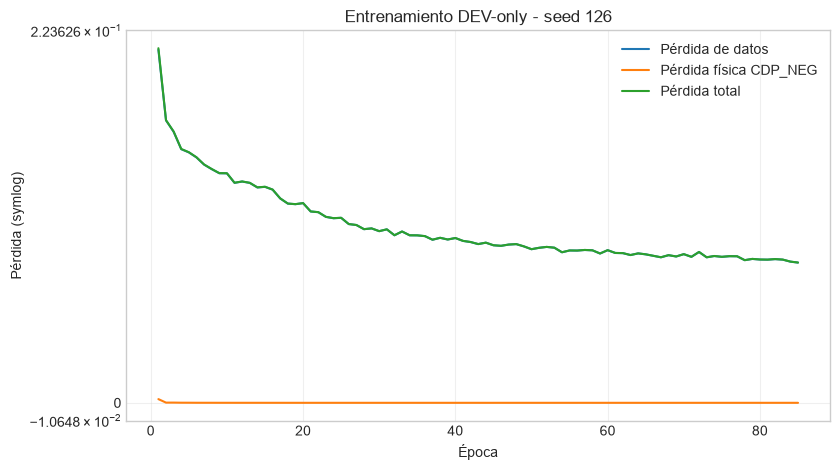

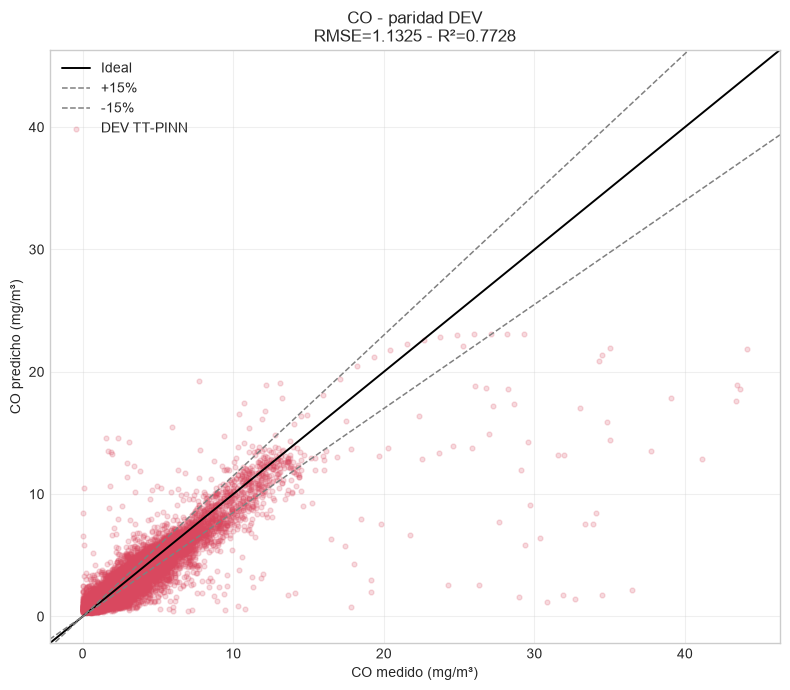

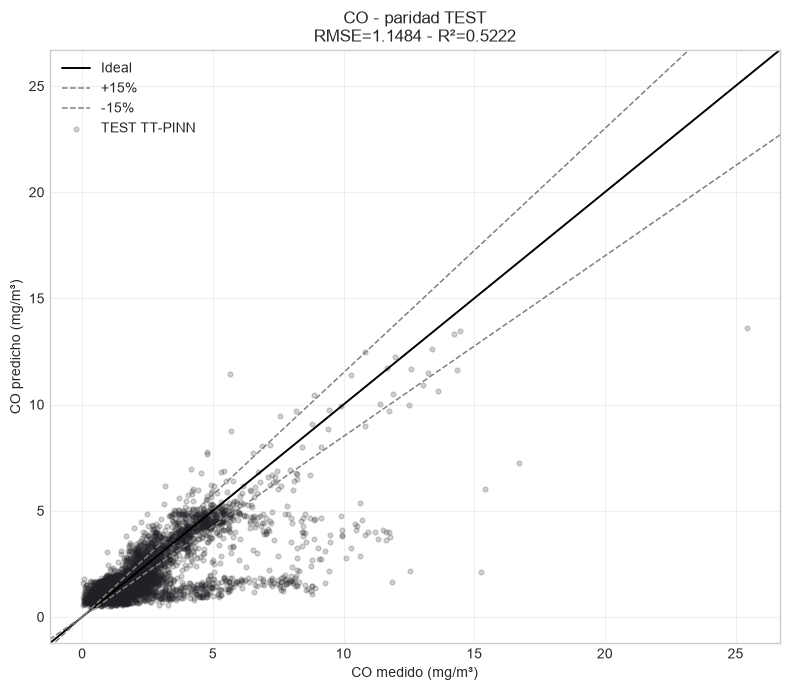

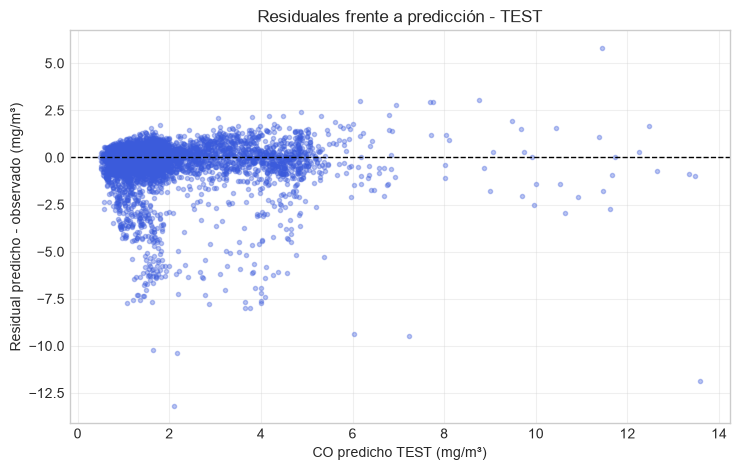

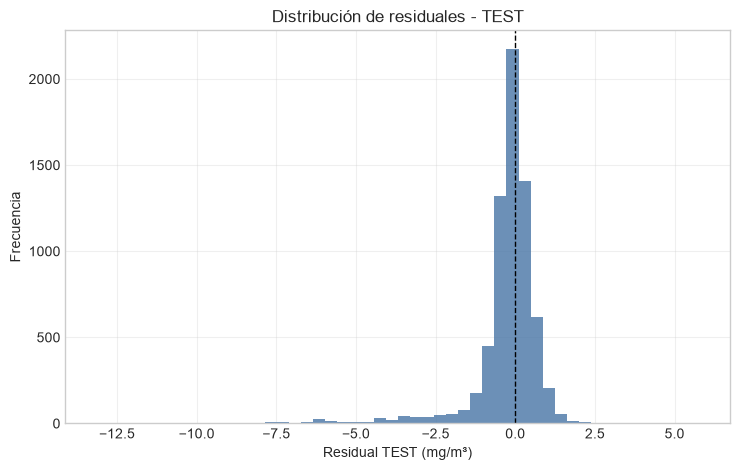

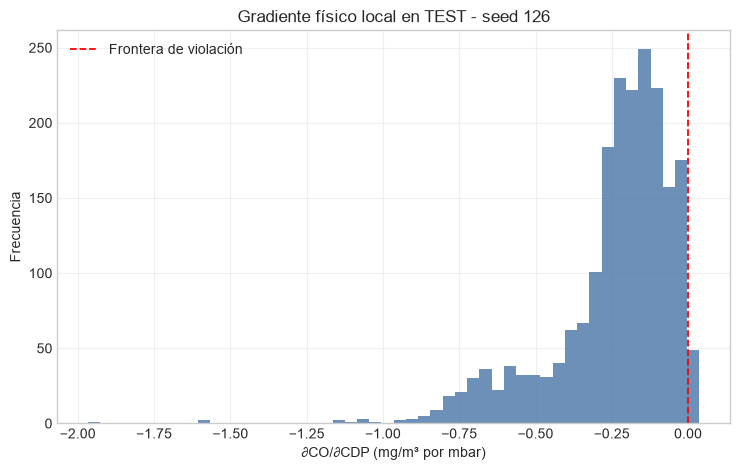

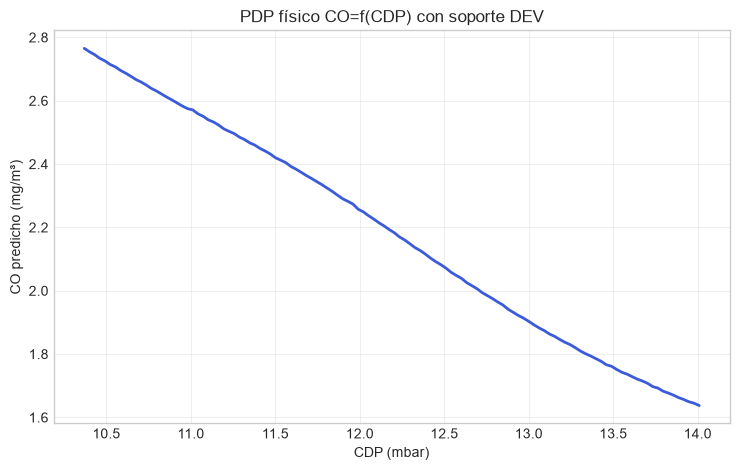

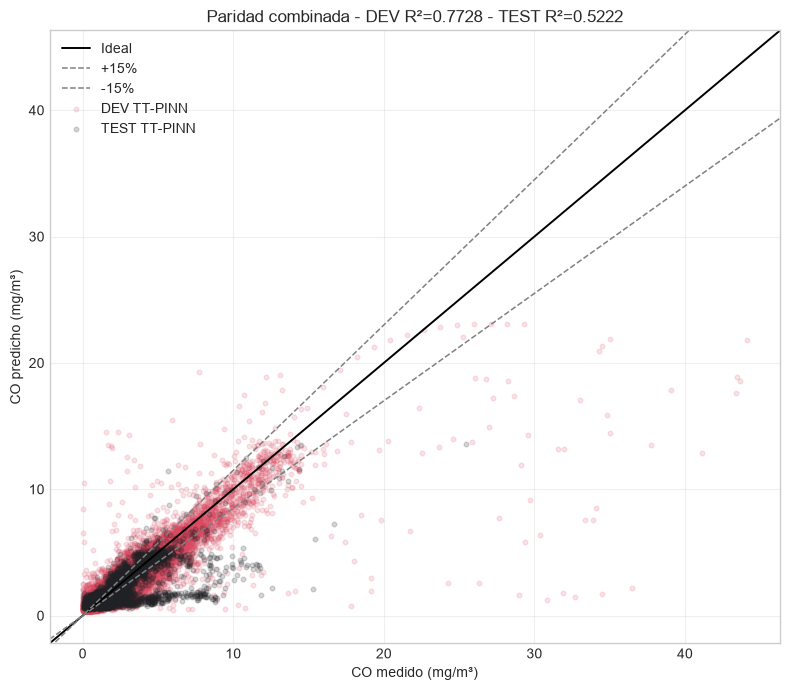

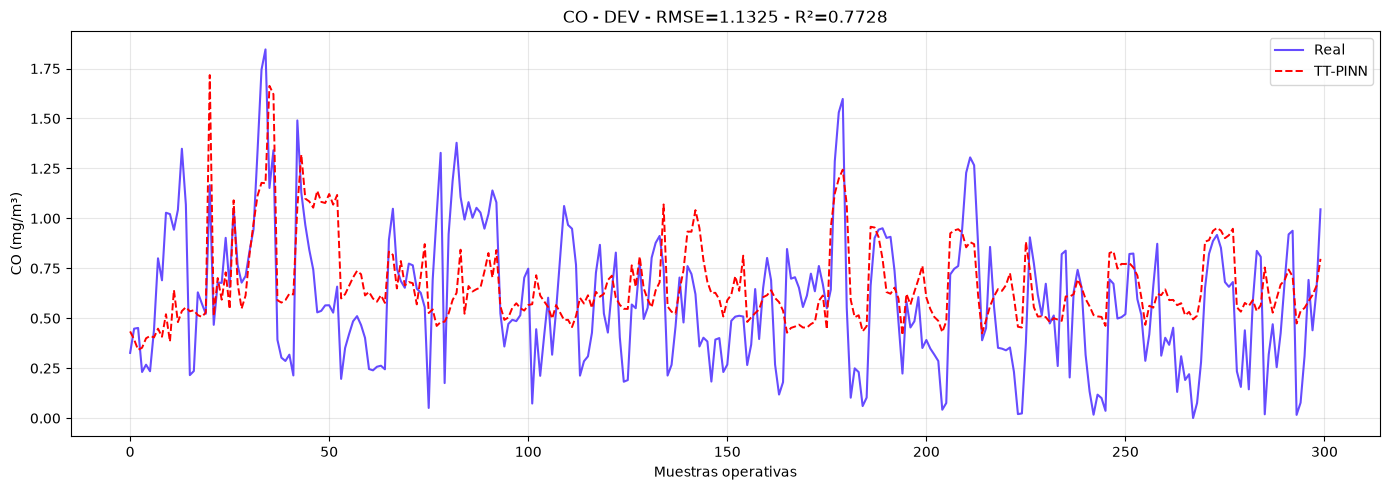

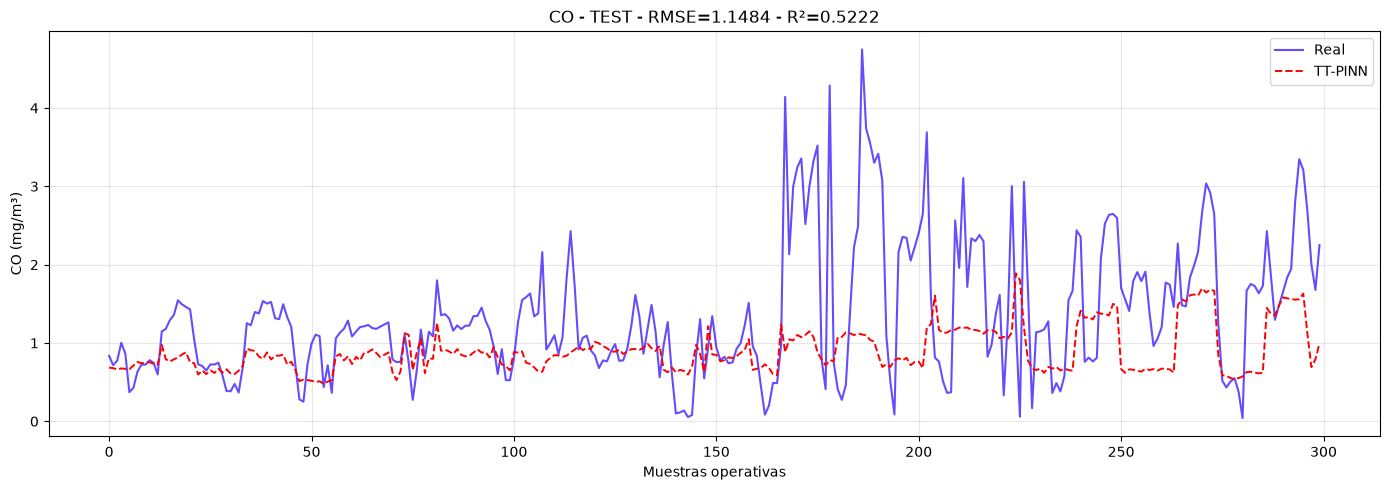

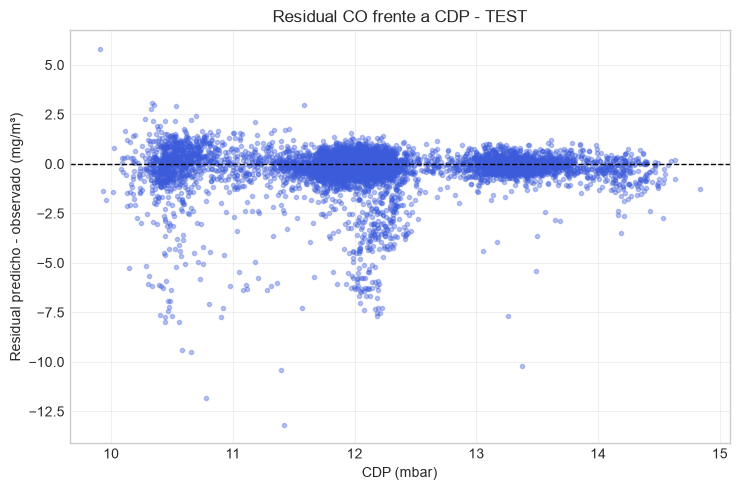

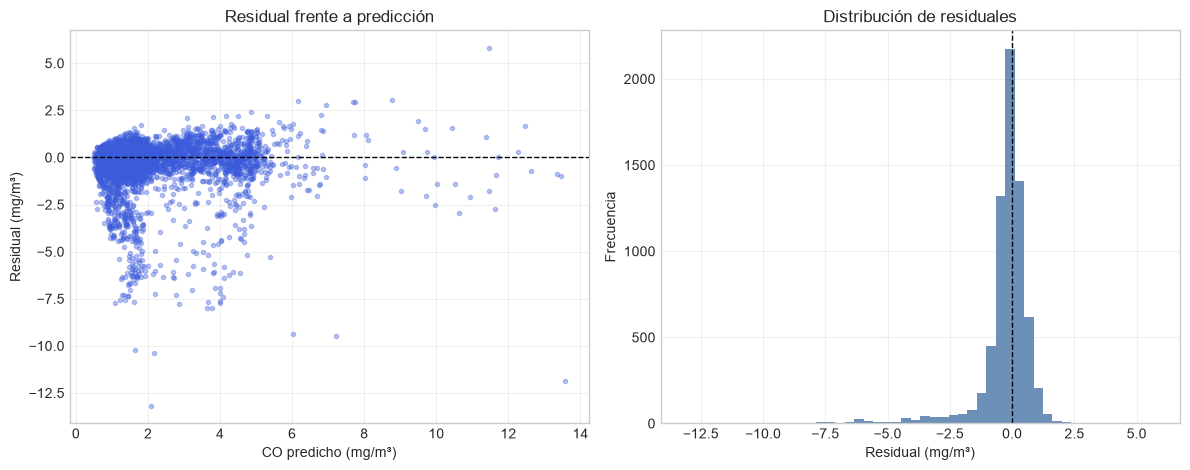

<USER_HOME>\AppData\Local\Temp\ipykernel_4236\3502529615.py:5: UserWarning: The figure layout has changed to tight
  figure.tight_layout()


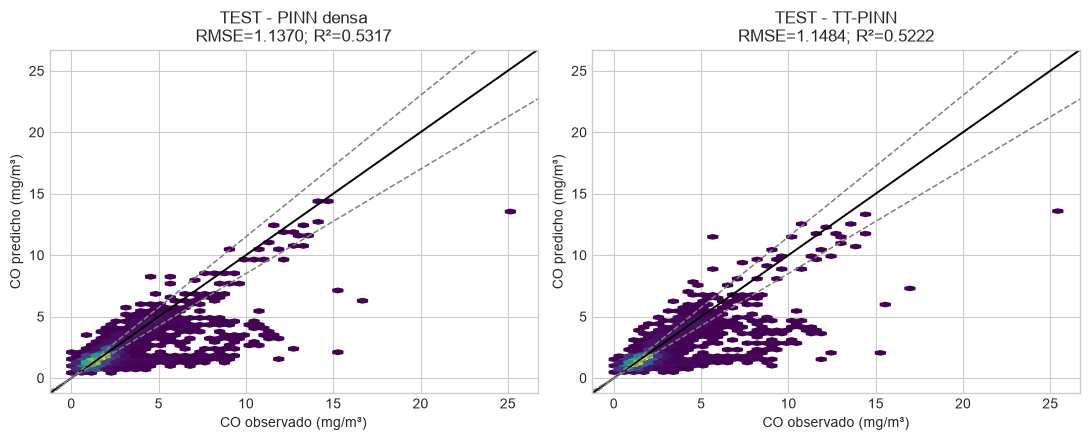

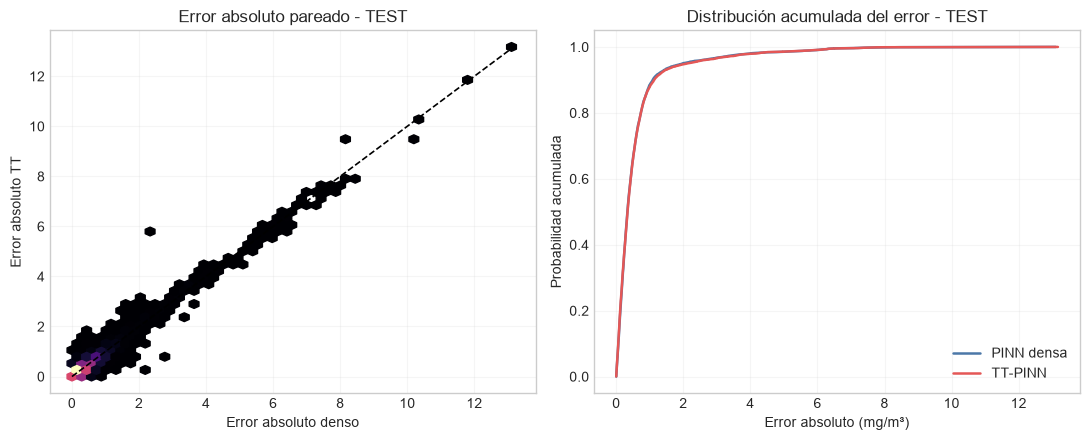

,figure_id,stem,role,producer_cell
0,FIG-01,FINAL-01_training_history,CANONICAL,C-11.01
1,FIG-02,FINAL-02_dev_parity,CANONICAL,C-11.01
2,FIG-03,FINAL-03_test_parity,CANONICAL,C-11.01
3,FIG-04,FINAL-04_test_residual_vs_predicted,CANONICAL,C-11.01
4,FIG-05,FINAL-05_test_residual_distribution,CANONICAL,C-11.01
5,FIG-06,FINAL-06_physical_gradient_distribution,CANONICAL,C-11.01
6,FIG-07,FINAL-07_physical_PDP_CDP,CANONICAL,C-11.01
7,FIG-08,FINAL-08_computational_profile,CANONICAL,C-11.02
8,FIG-09,FINAL-09_combined_parity_dev_test,CANONICAL,C-11.01
9,FIG-10,FINAL-10_dev_operational_series,CANONICAL,C-11.01


{'FIG-11': 'PASS', 'figuras canónicas en C-11.01': 12, 'FINAL-08 pendiente del perfil': True, 'suplementarias': 2, 'formatos': ['png', 'svg'], 'imágenes incrustadas': True}


In [18]:
# [C-11.01] Figuras canónicas FINAL-01 a FINAL-13 y suplementos TT
plt.style.use("seaborn-v0_8-whitegrid")

def save_figure(figure: plt.Figure, stem: str) -> None:
    figure.tight_layout()
    for extension in FIGURE_FORMATS:
        figure.savefig(
            PATHS.figures / f"{stem}.{extension}",
            dpi=220 if extension == "png" else None,
            bbox_inches="tight",
        )
    display(figure)
    plt.close(figure)

def parity_limits(*arrays: np.ndarray) -> tuple[list[float], np.ndarray]:
    finite = np.concatenate(
        [
            np.asarray(values, float)[np.isfinite(values)]
            for values in arrays
        ]
    )
    low, high = float(finite.min()), float(finite.max())
    span = max(high - low, np.finfo(float).eps)
    limits = [low - 0.05 * span, high + 0.05 * span]
    return limits, np.asarray(limits, float)

def add_parity_references(
    axis: plt.Axes,
    limits: list[float],
    limits_array: np.ndarray,
) -> None:
    axis.plot(limits, limits, color="black", linewidth=1.4, label="Ideal")
    axis.plot(
        limits_array,
        limits_array * 1.15,
        color="gray",
        linestyle="--",
        linewidth=1.1,
        label="+15%",
    )
    axis.plot(
        limits_array,
        limits_array * 0.85,
        color="gray",
        linestyle="--",
        linewidth=1.1,
        label="-15%",
    )

def parity_figure(
    observed: np.ndarray,
    predicted: np.ndarray,
    split_label: str,
    metrics: pd.Series,
    stem: str,
    color: str,
) -> None:
    limits, limits_array = parity_limits(observed, predicted)
    figure, axis = plt.subplots(figsize=(8, 7))
    add_parity_references(axis, limits, limits_array)
    axis.scatter(
        observed,
        predicted,
        color=color,
        s=12,
        alpha=0.2,
        label=f"{split_label} TT-PINN",
    )
    axis.set(
        xlim=limits,
        ylim=limits,
        xlabel=f"{TARGET_DISPLAY} medido (mg/m³)",
        ylabel=f"{TARGET_DISPLAY} predicho (mg/m³)",
        title=(
            f"{TARGET_DISPLAY} - paridad {split_label}\n"
            f"RMSE={float(metrics.RMSE):.4f} - "
            f"R²={float(metrics.R2):.4f}"
        ),
    )
    axis.grid(alpha=0.3)
    axis.legend()
    save_figure(figure, stem)

DEV_PLOT_METRICS = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("DEV")
].iloc[0]
TEST_PLOT_METRICS = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("TEST")
].iloc[0]

# FINAL-01 - las pérdidas adaptativas pueden ser negativas; symlog las conserva.
figure, axis = plt.subplots(figsize=(8.5, 4.8))
for column, label in [
    ("loss_data", "Pérdida de datos"),
    ("loss_physics", f"Pérdida física {PHYSICS_MODE}"),
    ("loss_total", "Pérdida total"),
]:
    axis.plot(TRAINING_HISTORY.epoch, TRAINING_HISTORY[column], label=label)
axis.set(
    xlabel="Época",
    ylabel="Pérdida (symlog)",
    title=f"Entrenamiento DEV-only - seed {REPRESENTATIVE_SEED}",
    yscale="symlog",
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-01_training_history")

# FINAL-02 y FINAL-03 - paridad DEV y TEST.
parity_figure(
    y_dev,
    dev_prediction,
    "DEV",
    DEV_PLOT_METRICS,
    "FINAL-02_dev_parity",
    "#d9485f",
)
parity_figure(
    y_test,
    test_prediction,
    "TEST",
    TEST_PLOT_METRICS,
    "FINAL-03_test_parity",
    "#202124",
)

# FINAL-04 y FINAL-05 - residuales TEST predicho menos observado.
test_residual = test_prediction - y_test
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.scatter(
    test_prediction,
    test_residual,
    s=9,
    alpha=0.35,
    color="#3b5bdb",
)
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel=f"{TARGET_DISPLAY} predicho TEST (mg/m³)",
    ylabel="Residual predicho - observado (mg/m³)",
    title="Residuales frente a predicción - TEST",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-04_test_residual_vs_predicted")

figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel="Residual TEST (mg/m³)",
    ylabel="Frecuencia",
    title="Distribución de residuales - TEST",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-05_test_residual_distribution")

# FINAL-06 - gradiente físico local en las mismas unidades del Gold Standard.
feature_unit = "°C" if PHYSICS_FEATURE == "TIT" else "mbar"
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(
    gradient_arrays["TEST"],
    bins=50,
    alpha=0.82,
    color="#4c78a8",
)
axis.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.3,
    label="Frontera de violación",
)
axis.set(
    xlabel=(
        f"∂{TARGET}/∂{PHYSICS_FEATURE} "
        f"(mg/m³ por {feature_unit})"
    ),
    ylabel="Frecuencia",
    title=(
        f"Gradiente físico local en TEST - "
        f"seed {REPRESENTATIVE_SEED}"
    ),
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-06_physical_gradient_distribution")

# FINAL-07 - PDP físico Q05-Q95 con covariables en la mediana DEV.
dev_median = DEV_DATA[FEATURES].median().to_numpy(float)
physics_index = FEATURES.index(PHYSICS_FEATURE)
grid_low, grid_high = np.quantile(
    DEV_DATA[PHYSICS_FEATURE],
    [0.05, 0.95],
)
physics_grid = np.linspace(grid_low, grid_high, PDP_POINTS)
pdp_inputs = np.tile(dev_median, (PDP_POINTS, 1))
pdp_inputs[:, physics_index] = physics_grid
pdp_prediction = predict_physical(
    FINAL_MODEL,
    pdp_inputs.astype(np.float32),
    X_SCALER,
    Y_SCALER,
    DEVICE,
)
PDP_TABLE_PATH = (
    PATHS.tables
    / f"PHYSICAL_PDP_{PHYSICS_FEATURE}_{ARTIFACT_TOKEN}.csv"
)
figure, axis = plt.subplots(figsize=(7.5, 4.8))
if TARGET == "NOX":
    dev_standardized = X_SCALER.transform(
        DEV_DATA[FEATURES].to_numpy(np.float32)
    )
    envelope, envelope_threshold, _ = fit_knn_envelope(
        dev_standardized,
        KNN_K,
        KNN_QUANTILE,
    )
    pdp_standardized = X_SCALER.transform(pdp_inputs)
    distances, _ = envelope.kneighbors(
        pdp_standardized,
        n_neighbors=min(KNN_K, len(dev_standardized)),
    )
    within_support = distances[:, -1] <= envelope_threshold
    PDP_TABLE = pd.DataFrame(
        {
            PHYSICS_FEATURE: physics_grid,
            f"predicted_{TARGET}_mg_m3": pdp_prediction,
            "knn_distance": distances[:, -1],
            "knn_threshold": envelope_threshold,
            "within_dev_knn_support": within_support,
        }
    )
    axis.plot(physics_grid, pdp_prediction, color="#b5b5b5", linestyle="--")
    axis.scatter(
        physics_grid[within_support],
        pdp_prediction[within_support],
        s=16,
        color="#3b5bdb",
        label="Dentro de soporte kNN DEV",
    )
    axis.scatter(
        physics_grid[~within_support],
        pdp_prediction[~within_support],
        s=16,
        color="#d9485f",
        label="Fuera de soporte kNN DEV",
    )
    axis.legend()
else:
    PDP_TABLE = pd.DataFrame(
        {
            PHYSICS_FEATURE: physics_grid,
            f"predicted_{TARGET}_mg_m3": pdp_prediction,
        }
    )
    axis.plot(physics_grid, pdp_prediction, linewidth=2, color="#3b5bdb")
atomic_csv(PDP_TABLE_PATH, PDP_TABLE)
axis.set(
    xlabel=f"{PHYSICS_FEATURE} ({feature_unit})",
    ylabel=f"{TARGET_DISPLAY} predicho (mg/m³)",
    title=(
        f"PDP físico {TARGET_DISPLAY}=f({PHYSICS_FEATURE}) "
        "con soporte DEV"
    ),
)
axis.grid(alpha=0.3)
save_figure(
    figure,
    f"FINAL-07_physical_PDP_{PHYSICS_FEATURE}",
)

# FINAL-09 - paridad DEV/TEST conjunta.
combined_limits, combined_array = parity_limits(
    y_dev,
    dev_prediction,
    y_test,
    test_prediction,
)
figure, axis = plt.subplots(figsize=(8, 7))
add_parity_references(axis, combined_limits, combined_array)
axis.scatter(
    y_dev,
    dev_prediction,
    color="#d9485f",
    s=11,
    alpha=0.15,
    label="DEV TT-PINN",
)
axis.scatter(
    y_test,
    test_prediction,
    color="#202124",
    s=11,
    alpha=0.18,
    label="TEST TT-PINN",
)
axis.set(
    xlim=combined_limits,
    ylim=combined_limits,
    xlabel=f"{TARGET_DISPLAY} medido (mg/m³)",
    ylabel=f"{TARGET_DISPLAY} predicho (mg/m³)",
    title=(
        f"Paridad combinada - DEV R²={float(DEV_PLOT_METRICS.R2):.4f} - "
        f"TEST R²={float(TEST_PLOT_METRICS.R2):.4f}"
    ),
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-09_combined_parity_dev_test")

# FINAL-10 y FINAL-11 - primeras 300 muestras en orden assignment-first.
def operational_series(
    observed: np.ndarray,
    predicted: np.ndarray,
    split_label: str,
    metrics: pd.Series,
    stem: str,
) -> None:
    count = min(300, len(observed), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            observed[:count],
            color="#4b2cff",
            alpha=0.85,
            label="Real",
        )
        axis.plot(
            predicted[:count],
            color="red",
            linestyle="--",
            linewidth=1.4,
            label="TT-PINN",
        )
        axis.set(
            xlabel="Muestras operativas",
            ylabel=f"{TARGET_DISPLAY} (mg/m³)",
            title=(
                f"{TARGET_DISPLAY} - {split_label} - "
                f"RMSE={float(metrics.RMSE):.4f} - "
                f"R²={float(metrics.R2):.4f}"
            ),
        )
        axis.grid(alpha=0.3)
        axis.legend()
        save_figure(figure, stem)

operational_series(
    y_dev,
    dev_prediction,
    "DEV",
    DEV_PLOT_METRICS,
    "FINAL-10_dev_operational_series",
)
operational_series(
    y_test,
    test_prediction,
    "TEST",
    TEST_PLOT_METRICS,
    "FINAL-11_test_operational_series",
)

# FINAL-12 - CDP es diagnóstico no vinculante también para NOx.
figure, axis = plt.subplots(figsize=(7.5, 5))
axis.scatter(
    TEST_PREDICTIONS["CDP"],
    test_residual,
    s=9,
    alpha=0.35,
    color="#3b5bdb",
)
axis.axhline(0, linestyle="--", color="black", linewidth=1)
axis.set(
    title=f"Residual {TARGET_DISPLAY} frente a CDP - TEST",
    xlabel="CDP (mbar)",
    ylabel="Residual predicho - observado (mg/m³)",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-12_test_residual_vs_CDP")

# FINAL-13 - panel residual combinado.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(
    test_prediction,
    test_residual,
    s=9,
    alpha=0.35,
    color="#3b5bdb",
)
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set(
    title="Residual frente a predicción",
    xlabel=f"{TARGET_DISPLAY} predicho (mg/m³)",
    ylabel="Residual (mg/m³)",
)
axes[1].hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="Distribución de residuales",
    xlabel="Residual (mg/m³)",
    ylabel="Frecuencia",
)
for axis in axes:
    axis.grid(alpha=0.3)
save_figure(figure, "FINAL-13_test_residual_diagnostics")

# Suplemento 01 - paridad densa/TT, sin sustituir las vistas canónicas.
paired_observed = PAIRED_TEST_PREDICTIONS["tt_observed"].to_numpy(float)
dense_prediction = PAIRED_TEST_PREDICTIONS["dense_prediction"].to_numpy(float)
tt_prediction = PAIRED_TEST_PREDICTIONS["tt_prediction"].to_numpy(float)
supplement_limits, _ = parity_limits(
    paired_observed,
    dense_prediction,
    tt_prediction,
)
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for axis, prediction, title, metrics_row in [
    (axes[0], dense_prediction, "PINN densa", dense_test_metrics),
    (axes[1], tt_prediction, "TT-PINN", tt_test_metrics),
]:
    axis.hexbin(
        paired_observed,
        prediction,
        gridsize=45,
        mincnt=1,
        cmap="viridis",
    )
    add_parity_references(
        axis,
        supplement_limits,
        np.asarray(supplement_limits, float),
    )
    axis.set(
        xlim=supplement_limits,
        ylim=supplement_limits,
        xlabel=f"{TARGET_DISPLAY} observado (mg/m³)",
        ylabel=f"{TARGET_DISPLAY} predicho (mg/m³)",
        title=(
            f"TEST - {title}\n"
            f"RMSE={float(metrics_row['RMSE']):.4f}; "
            f"R²={float(metrics_row['R2']):.4f}"
        ),
    )
save_figure(
    figure,
    f"SUPPLEMENTAL-01_dense_vs_tt_parity_{ARTIFACT_TOKEN}",
)

# Suplemento 02 - dos vistas del mismo error absoluto pareado.
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
dense_absolute_error = PAIRED_TEST_PREDICTIONS[
    "dense_abs_error"
].to_numpy(float)
tt_absolute_error = PAIRED_TEST_PREDICTIONS[
    "tt_abs_error"
].to_numpy(float)
axes[0].hexbin(
    dense_absolute_error,
    tt_absolute_error,
    gridsize=45,
    mincnt=1,
    cmap="magma",
)
error_limit = float(
    max(
        dense_absolute_error.max(),
        tt_absolute_error.max(),
    )
)
axes[0].plot([0, error_limit], [0, error_limit], "k--", linewidth=1.2)
axes[0].set(
    xlabel="Error absoluto denso",
    ylabel="Error absoluto TT",
    title="Error absoluto pareado - TEST",
)
sorted_dense_error = np.sort(dense_absolute_error)
sorted_tt_error = np.sort(tt_absolute_error)
dense_ecdf = np.arange(1, len(sorted_dense_error) + 1) / len(
    sorted_dense_error
)
tt_ecdf = np.arange(1, len(sorted_tt_error) + 1) / len(sorted_tt_error)
axes[1].plot(
    sorted_dense_error,
    dense_ecdf,
    color="#4C78A8",
    label="PINN densa",
    linewidth=1.8,
)
axes[1].plot(
    sorted_tt_error,
    tt_ecdf,
    color="#E45756",
    label="TT-PINN",
    linewidth=1.8,
)
axes[1].set(
    xlabel="Error absoluto (mg/m³)",
    ylabel="Probabilidad acumulada",
    title="Distribución acumulada del error - TEST",
)
axes[1].legend()
for axis in axes:
    axis.grid(alpha=0.18)
save_figure(
    figure,
    f"SUPPLEMENTAL-02_paired_absolute_error_{ARTIFACT_TOKEN}",
)
FIGURE_CATALOG = pd.DataFrame(
    [
        ("FIG-01", "FINAL-01_training_history", "CANONICAL", "C-11.01"),
        ("FIG-02", "FINAL-02_dev_parity", "CANONICAL", "C-11.01"),
        ("FIG-03", "FINAL-03_test_parity", "CANONICAL", "C-11.01"),
        (
            "FIG-04",
            "FINAL-04_test_residual_vs_predicted",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-05",
            "FINAL-05_test_residual_distribution",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-06",
            "FINAL-06_physical_gradient_distribution",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-07",
            f"FINAL-07_physical_PDP_{PHYSICS_FEATURE}",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-08",
            "FINAL-08_computational_profile",
            "CANONICAL",
            "C-11.02",
        ),
        (
            "FIG-09",
            "FINAL-09_combined_parity_dev_test",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-10",
            "FINAL-10_dev_operational_series",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-11",
            "FINAL-11_test_operational_series",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-12",
            "FINAL-12_test_residual_vs_CDP",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-13",
            "FINAL-13_test_residual_diagnostics",
            "CANONICAL",
            "C-11.01",
        ),
        (
            "FIG-S01",
            f"SUPPLEMENTAL-01_dense_vs_tt_parity_{ARTIFACT_TOKEN}",
            "SUPPLEMENTAL",
            "C-11.01",
        ),
        (
            "FIG-S02",
            f"SUPPLEMENTAL-02_paired_absolute_error_{ARTIFACT_TOKEN}",
            "SUPPLEMENTAL",
            "C-11.01",
        ),
    ],
    columns=["figure_id", "stem", "role", "producer_cell"],
)
display(FIGURE_CATALOG)
print(
    {
        "FIG-11": "PASS",
        "figuras canónicas en C-11.01": 12,
        "FINAL-08 pendiente del perfil": True,
        "suplementarias": SUPPLEMENTAL_FIGURE_COUNT,
        "formatos": list(FIGURE_FORMATS),
        "imágenes incrustadas": True,
    }
)


### C-11.02 - Perfil homogéneo densa/TT

**Finalidad:** comparar almacenamiento, latencia y throughput en igualdad.
**Entradas:** ambos checkpoints, mismas filas, dispositivo y dtype.
**Salidas:** perfil CSV/JSON y figura canónica FINAL-08.
**Control y parada:** warm-up y repeticiones son idénticos para ambos modelos.


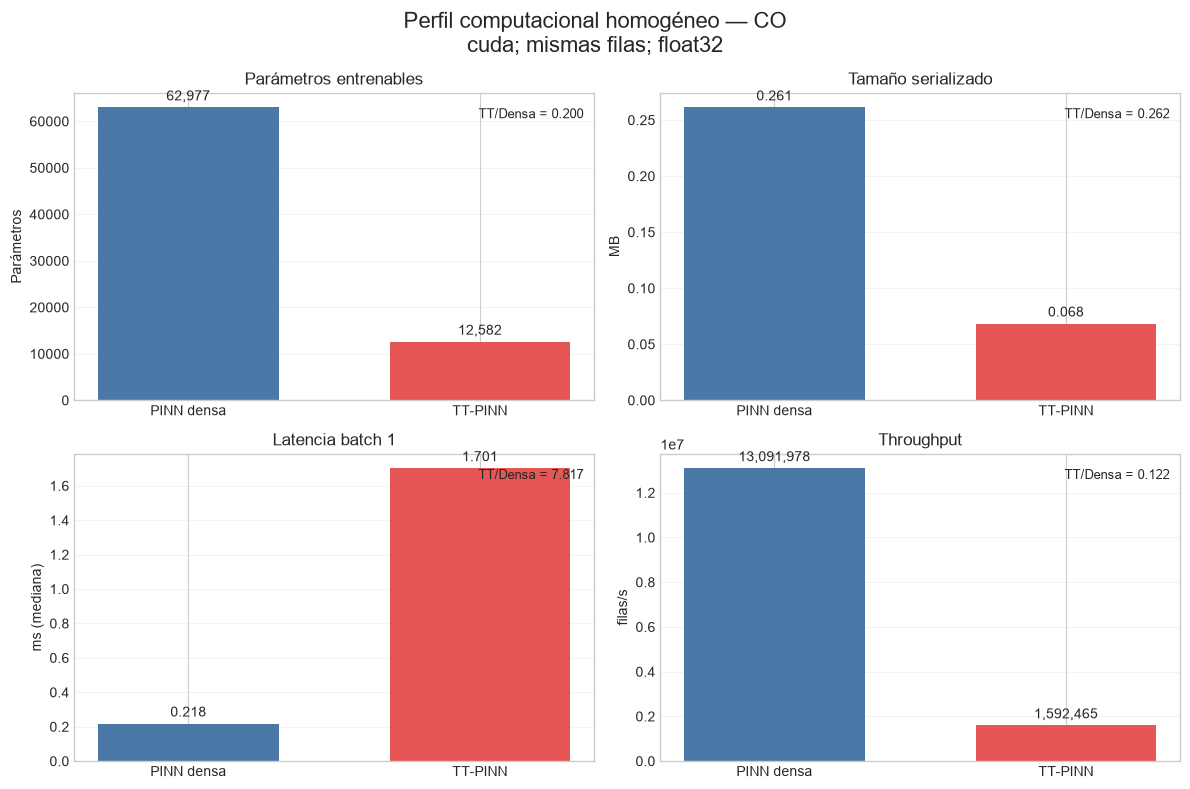

,model_family,device,parameter_count,parameter_bytes_float32,state_dict_bytes,checkpoint_bytes,latency_batch1_median_ms,latency_batch1_p95_ms,throughput_rows_s,benchmark_rows,latency_repetitions,throughput_repetitions
0,DENSE_PINN,cuda,62977,251908,255871,261215,0.21765,0.627965,1.309198e+07,4096,200,30
1,TT_PINN,cuda,12582,50328,59843,68373,1.70145,3.533130,1.592465e+06,4096,200,30


{'FIG-11.02': 'PASS', 'figuras canónicas acumuladas': 13, 'figuras suplementarias acumuladas': 2, 'archivos de figura esperados': 30}


In [19]:
# [C-11.02] Perfil homogéneo de almacenamiento, latencia y throughput
class DenseReferencePINN(nn.Module):
    def __init__(self, input_dim: int, config: dict, seed: int) -> None:
        super().__init__()
        set_seed(seed)
        self.config = copy.deepcopy(config)
        if config.get("physics_weighting") == "ADAPTIVE_LEARNED":
            self.log_var_data = nn.Parameter(torch.zeros(()))
            self.log_var_physics = nn.Parameter(torch.zeros(()))
        else:
            self.register_parameter("log_var_data", None)
            self.register_parameter("log_var_physics", None)
        self.fourier_dim = int(config.get("fourier_dim", 0))
        if self.fourier_dim:
            generator = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(
                    input_dim,
                    self.fourier_dim,
                    generator=generator,
                ) * float(config["fourier_scale"]),
            )
            dimension = 2 * self.fourier_dim
        else:
            dimension = input_dim
        activations = {
            "tanh": nn.Tanh,
            "silu": nn.SiLU,
            "gelu": nn.GELU,
            "softplus": nn.Softplus,
        }
        layers = []
        for width in config["hidden_widths"]:
            layers.extend(
                [nn.Linear(dimension, int(width)), activations[config["activation"]]()]
            )
            if (
                float(config.get("dropout", 0.0)) > 0
                and config.get("physics_dropout_mode") != "no_dropout"
            ):
                layers.append(nn.Dropout(float(config["dropout"])))
            dimension = int(width)
        layers.append(nn.Linear(dimension, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if self.fourier_dim:
            projection = 2 * math.pi * inputs @ self.fourier_B
            inputs = torch.cat(
                [torch.sin(projection), torch.cos(projection)],
                dim=1,
            )
        output = self.net(inputs).squeeze(-1)
        if self.config.get("nonnegative_output") == "softplus_output":
            return F.softplus(output)
        return output

def synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)

def benchmark_latency(
    model: nn.Module,
    standardized_row: torch.Tensor,
    device: torch.device,
) -> tuple[float, float]:
    model.eval()
    with torch.no_grad():
        for _ in range(LATENCY_WARMUP):
            model(standardized_row)
        synchronize(device)
        timings = []
        for _ in range(LATENCY_REPETITIONS):
            synchronize(device)
            started = time.perf_counter()
            model(standardized_row)
            synchronize(device)
            timings.append((time.perf_counter() - started) * 1000.0)
    return float(np.median(timings)), float(np.quantile(timings, 0.95))

def benchmark_throughput(
    model: nn.Module,
    standardized_values: torch.Tensor,
    device: torch.device,
) -> float:
    model.eval()
    with torch.no_grad():
        for _ in range(THROUGHPUT_WARMUP):
            model(standardized_values)
        synchronize(device)
        started = time.perf_counter()
        for _ in range(THROUGHPUT_REPETITIONS):
            model(standardized_values)
        synchronize(device)
    elapsed = time.perf_counter() - started
    return float(
        THROUGHPUT_REPETITIONS * len(standardized_values) / elapsed
    )

dense_package = torch.load(
    FROZEN["dense_model_path"],
    map_location=DEVICE,
    weights_only=False,
)
dense_model = DenseReferencePINN(
    len(FEATURES),
    BEST_CONFIG,
    REPRESENTATIVE_SEED,
).to(DEVICE)
dense_model.load_state_dict(dense_package["state_dict"])
dense_model.eval()
dense_x_scaler = scaler_from_state(dense_package["x_scaler"])
probe_physical = x_test[: min(4096, len(x_test))]
dense_probe = torch.from_numpy(
    dense_x_scaler.transform(probe_physical).astype(np.float32)
).to(DEVICE)
tt_probe = torch.from_numpy(
    X_SCALER.transform(probe_physical).astype(np.float32)
).to(DEVICE)

profile_rows = []
for family, model, probe, checkpoint, state_dict in [
    (
        "DENSE_PINN",
        dense_model,
        dense_probe,
        FROZEN["dense_model_path"],
        dense_package["state_dict"],
    ),
    ("TT_PINN", FINAL_MODEL, tt_probe, MODEL_PATH, MODEL_PACKAGE["state_dict"]),
]:
    median_ms, p95_ms = benchmark_latency(model, probe[:1], DEVICE)
    throughput = benchmark_throughput(model, probe, DEVICE)
    profile_rows.append(
        {
            "model_family": family,
            "device": str(DEVICE),
            "parameter_count": count_parameters(model),
            "parameter_bytes_float32": count_parameters(model) * 4,
            "state_dict_bytes": serialized_torch_bytes(state_dict),
            "checkpoint_bytes": Path(checkpoint).stat().st_size,
            "latency_batch1_median_ms": median_ms,
            "latency_batch1_p95_ms": p95_ms,
            "throughput_rows_s": throughput,
            "benchmark_rows": len(probe),
            "latency_repetitions": LATENCY_REPETITIONS,
            "throughput_repetitions": THROUGHPUT_REPETITIONS,
        }
    )
RESOURCE_PROFILE = pd.DataFrame(profile_rows)
atomic_csv(
    PATHS.tables / f"RESOURCE_PROFILE_{ARTIFACT_TOKEN}.csv",
    RESOURCE_PROFILE,
)
MODEL_PROFILE = {
    "status": "COMPLETE",
    "generated_at_utc": utc_now(),
    "version": VERSION,
    "target": TARGET,
    "comparison_policy": "SAME_DEVICE_SAME_ROWS_FLOAT32_IN_MEMORY_STATE_DICT",
    "environment": ENVIRONMENT,
    "tt_contract_hash": TT_CONTRACT_HASH,
    "profiles": RESOURCE_PROFILE.to_dict(orient="records"),
}
atomic_json(
    PATHS.configs / f"MODEL_PROFILE_{TARGET}_TT_PINN_INTERP_R1F_STD.json",
    MODEL_PROFILE,
)

# FINAL-08 - perfil homogéneo densa/TT sobre el mismo dispositivo y filas.
dense_profile = RESOURCE_PROFILE.loc[
    RESOURCE_PROFILE["model_family"].eq("DENSE_PINN")
].iloc[0]
tt_profile = RESOURCE_PROFILE.loc[
    RESOURCE_PROFILE["model_family"].eq("TT_PINN")
].iloc[0]
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
profile_panels = [
    (
        "Parámetros entrenables",
        "parameter_count",
        1.0,
        "Parámetros",
        lambda value: f"{int(value):,}",
    ),
    (
        "Tamaño serializado",
        "checkpoint_bytes",
        1e6,
        "MB",
        lambda value: f"{value:.3f}",
    ),
    (
        "Latencia batch 1",
        "latency_batch1_median_ms",
        1.0,
        "ms (mediana)",
        lambda value: f"{value:.3f}",
    ),
    (
        "Throughput",
        "throughput_rows_s",
        1.0,
        "filas/s",
        lambda value: f"{value:,.0f}",
    ),
]
for axis, (title, column, divisor, unit, formatter) in zip(
    axes.flat,
    profile_panels,
):
    values = np.asarray(
        [
            float(dense_profile[column]) / divisor,
            float(tt_profile[column]) / divisor,
        ],
        dtype=float,
    )
    bars = axis.bar(
        ["PINN densa", "TT-PINN"],
        values,
        color=["#4C78A8", "#E45756"],
        width=0.62,
    )
    if float(values.max() / values.min()) >= 20.0:
        axis.set_yscale("log")
    axis.bar_label(
        bars,
        labels=[formatter(value) for value in values],
        padding=3,
        fontsize=10,
    )
    axis.set(title=title, ylabel=unit)
    axis.grid(axis="y", alpha=0.22)
    axis.text(
        0.98,
        0.95,
        f"TT/Densa = {values[1] / values[0]:.3f}",
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )
figure.suptitle(
    (
        f"Perfil computacional homogéneo — {TARGET_DISPLAY}\n"
        f"{DEVICE}; mismas filas; float32"
    ),
    fontsize=16,
)
save_figure(figure, "FINAL-08_computational_profile")
display(RESOURCE_PROFILE)
print(
    {
        "FIG-11.02": "PASS",
        "figuras canónicas acumuladas": CANONICAL_FIGURE_COUNT,
        "figuras suplementarias acumuladas": SUPPLEMENTAL_FIGURE_COUNT,
        "archivos de figura esperados": (
            CANONICAL_FIGURE_COUNT + SUPPLEMENTAL_FIGURE_COUNT
        ) * len(FIGURE_FORMATS),
    }
)


## SEC-12 - Reporte, manifiesto y cierre


### C-12.01 - Reporte técnico

**Finalidad:** hacer explícitos alcance, resultados y supuestos.
**Entradas:** métricas, contrato, comparación y hash de fuente.
**Salidas:** declaración JSON e informe Markdown.
**Control y parada:** declara honestamente el uso histórico de TEST por la densa.


In [20]:
# [C-12.01] Declaración de alcance y reporte técnico reproducible
SCOPE_DECLARATION = {
    "status": "FINAL_EXECUTED_SCOPE_DECLARATION",
    "version": VERSION,
    "target": TARGET,
    "model_family": "TT_PINN",
    "single_model": True,
    "representative_seed_count": 1,
    "ensemble_used": False,
    "hyperparameter_search_performed": False,
    "rank_selected_with_predictive_metrics": False,
    "test_used_for_adjustment": False,
    "retraining_after_test": False,
    "input_layer_dense": True,
    "output_layer_dense": True,
    "hidden_to_hidden_layers_tt": True,
    "forward_dense_reconstruction": False,
    "dense_baseline_test_was_historically_open": True,
    "tt_execution_test_access_count": 1,
    "engineering_margins": NON_INFERIORITY_CONTRACT,
}
atomic_json(
    PATHS.configs / f"EXPERIMENT_SCOPE_{ARTIFACT_TOKEN}.json",
    SCOPE_DECLARATION,
)
source_notebook_path = PROJECT_ROOT / "notebooks" / CURRENT_NOTEBOOK_NAME
if not source_notebook_path.is_file():
    raise FileNotFoundError(f"Fuente del notebook ausente: {source_notebook_path}")
SOURCE_NOTEBOOK_SHA256 = sha256_file(source_notebook_path)
test_metrics_report = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("TEST")
].to_dict(orient="records")[0]
test_physics_report = PHYSICS_AUDIT.loc[
    PHYSICS_AUDIT.split.eq("TEST")
].to_dict(orient="records")[0]
report_lines = [
    f"# Informe técnico - {TARGET_DISPLAY} TT-PINN R1F_STD",
    "",
    "## Identidad y alcance",
    "",
    f"- Versión: `{VERSION}`.",
    f"- Fuente: `{CURRENT_NOTEBOOK_NAME}`.",
    f"- SHA-256 de la fuente: `{SOURCE_NOTEBOOK_SHA256}`.",
    f"- Derivación: baseline densa autenticada `{DENSE_FINAL_NOTEBOOK_NAME}`.",
    f"- Semilla/épocas heredadas: `{REPRESENTATIVE_SEED}` / `{FINAL_EPOCHS}`.",
    "- Modelos TT entrenados: `1`; ensembles: `0`.",
    "- Búsqueda o selección TT por métricas: `False`.",
    "",
    "## Contrato Tensor-Train",
    "",
    f"- Formato: `{TT_CONTRACT['tensor_format']}`.",
    f"- Orden: `{TT_ORDER}`; rango uniforme: `{SELECTED_TT_RANK}`.",
    (
        "- Parámetros densos/TT: "
        f"`{TT_CONTRACT['dense_parameters']}` / "
        f"`{TT_CONTRACT['expected_tt_parameters']}`."
    ),
    "- Reconstrucción densa en `forward`: `False`.",
    "- Entrada, salida y sesgos: densos; transiciones ocultas: TT.",
    "",
    "## TEST y resultados",
    "",
    "TEST se materializó una vez dentro de esta ejecución TT después de firmar,",
    "serializar y recargar el modelo. La baseline densa ya había utilizado TEST",
    "en su ejecución histórica; el notebook no afirma virginidad global.",
    "",
    "Métricas TT TEST:",
    "",
    "```text",
    json.dumps(test_metrics_report, ensure_ascii=False, indent=2, default=str),
    "```",
    "",
    "Física TT TEST:",
    "",
    "```text",
    json.dumps(test_physics_report, ensure_ascii=False, indent=2, default=str),
    "```",
    "",
    "Comparación densa/TT:",
    "",
    "```text",
    MODEL_COMPARISON.to_csv(index=False),
    "```",
    "",
    f"No inferioridad predeclarada: `{NON_INFERIORITY_STATUS}`. Los márgenes",
    "son supuestos de ingeniería R1F_STD, no valores del artículo TT-PINN ni",
    "una norma PEMS. El resultado es informativo y nunca activa ajuste.",
    "",
    "## Cierre de gobernanza",
    "",
    "- Modelo, configuración y contrato TT conservaron sus hashes post-TEST.",
    "- TEST no eligió rango, arquitectura, seed, épocas ni hiperparámetros.",
    "- No hubo búsqueda, ranking, ensemble ni reentrenamiento post-TEST.",
]
report = "\n".join(report_lines) + "\n"
REPORT_PATH = PATHS.reports / f"TECHNICAL_REPORT_{ARTIFACT_TOKEN}.md"
atomic_text(REPORT_PATH, report)
print({"REPORT-12": "PASS", "ruta": str(REPORT_PATH)})


{'REPORT-12': 'PASS', 'ruta': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\interp\\work_tt_pinn_co_interp_final_r1f_std\\reports\\TECHNICAL_REPORT_CO_TT_R1F_STD.md'}


### C-12.02 - Publicación transaccional

**Finalidad:** cerrar el ledger y firmar todos los artefactos.
**Entradas:** salidas obligatorias, figuras, hashes y auditorías.
**Salidas:** tabla de hashes y manifiesto final `COMPLETE`.
**Control y parada:** se detiene ante cualquier salida ausente o mutación.


In [21]:
# [C-12.02] Manifiesto final, hashes y cierre transaccional
required_outputs = [
    MODEL_PATH,
    TT_CONTRACT_PATH,
    PATHS.tables / f"FINAL_METRICS_{ARTIFACT_TOKEN}.csv",
    PATHS.tables / f"PHYSICS_AUDIT_{ARTIFACT_TOKEN}.csv",
    PATHS.tables / f"DENSE_VS_TT_COMPARISON_{ARTIFACT_TOKEN}.csv",
    PATHS.tables / f"NON_INFERIORITY_AUDIT_{ARTIFACT_TOKEN}.csv",
    PATHS.tables / f"RESOURCE_PROFILE_{ARTIFACT_TOKEN}.csv",
    PDP_TABLE_PATH,
    PATHS.configs / f"MODEL_PROFILE_{TARGET}_TT_PINN_INTERP_R1F_STD.json",
    PATHS.configs / f"EXPERIMENT_SCOPE_{ARTIFACT_TOKEN}.json",
    PATHS.audit / PRE_TEST_GATE_FILENAME,
    PATHS.audit / f"TEST_ACCESS_AUDIT_{ARTIFACT_TOKEN}.json",
    PATHS.audit / f"EVALUATION_DECISION_AUDIT_{ARTIFACT_TOKEN}.json",
    REPORT_PATH,
]
CANONICAL_FIGURE_STEMS = [
    "FINAL-01_training_history",
    "FINAL-02_dev_parity",
    "FINAL-03_test_parity",
    "FINAL-04_test_residual_vs_predicted",
    "FINAL-05_test_residual_distribution",
    "FINAL-06_physical_gradient_distribution",
    f"FINAL-07_physical_PDP_{PHYSICS_FEATURE}",
    "FINAL-08_computational_profile",
    "FINAL-09_combined_parity_dev_test",
    "FINAL-10_dev_operational_series",
    "FINAL-11_test_operational_series",
    "FINAL-12_test_residual_vs_CDP",
    "FINAL-13_test_residual_diagnostics",
]
SUPPLEMENTAL_FIGURE_STEMS = [
    f"SUPPLEMENTAL-01_dense_vs_tt_parity_{ARTIFACT_TOKEN}",
    f"SUPPLEMENTAL-02_paired_absolute_error_{ARTIFACT_TOKEN}",
]
expected_figure_files = [
    PATHS.figures / f"{stem}.{extension}"
    for stem in CANONICAL_FIGURE_STEMS + SUPPLEMENTAL_FIGURE_STEMS
    for extension in FIGURE_FORMATS
]
expected_figure_set = set(expected_figure_files)
figure_files = sorted(
    path for path in PATHS.figures.iterdir() if path.is_file()
)
missing_figure_files = [
    str(path) for path in expected_figure_files if not path.is_file()
]
unexpected_figure_files = [
    str(path) for path in figure_files if path not in expected_figure_set
]
missing = [str(path) for path in required_outputs if not path.is_file()]
expected_figure_file_count = (
    CANONICAL_FIGURE_COUNT + SUPPLEMENTAL_FIGURE_COUNT
) * len(FIGURE_FORMATS)
if (
    missing
    or missing_figure_files
    or unexpected_figure_files
    or len(figure_files) != expected_figure_file_count
):
    raise RuntimeError(
        "Cierre incompleto; "
        f"ausentes={missing}; "
        f"figuras_ausentes={missing_figure_files}; "
        f"figuras_inesperadas={unexpected_figure_files}; "
        f"figuras={len(figure_files)}/{expected_figure_file_count}"
    )
if sha256_file(MODEL_PATH) != PRE_TEST_HASHES["model_sha256"]:
    raise RuntimeError("El modelo cambió antes del manifiesto")
if read_json(TEST_LEDGER_PATH).get("state") != "TT_TEST_EVALUATED_IMMUTABLE":
    raise RuntimeError("El ledger TT no está listo para cierre")

update_test_ledger(
    "TT_RUN_COMPLETE",
    completed_at_utc=utc_now(),
    model_changed_after_test=False,
    retraining_after_test=False,
    test_used_for_adjustment=False,
)
manifest_path = PATHS.configs / f"FINAL_MODEL_MANIFEST_{ARTIFACT_TOKEN}.json"
hash_table_path = PATHS.tables / f"ARTIFACT_HASHES_{ARTIFACT_TOKEN}.csv"
artifact_paths = sorted(
    path
    for path in PATHS.work.rglob("*")
    if path.is_file() and path not in {manifest_path, hash_table_path}
)
ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "relative_path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in artifact_paths
    ]
)
atomic_csv(hash_table_path, ARTIFACT_HASHES)
final_test_metrics = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("TEST")
].to_dict(orient="records")[0]
final_test_physics = PHYSICS_AUDIT.loc[
    PHYSICS_AUDIT.split.eq("TEST")
].to_dict(orient="records")[0]
FINAL_MANIFEST = {
    "status": "COMPLETE",
    "generated_at_utc": utc_now(),
    "version": VERSION,
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "producer_notebook_sha256": SOURCE_NOTEBOOK_SHA256,
    "model_family": "TT_PINN",
    "target": TARGET,
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "dense_final_notebook": DENSE_FINAL_NOTEBOOK_NAME,
    "derivation_role": "INDIRECT_DERIVATIVE_OF_AUTHENTICATED_DENSE_FINAL",
    "dense_final_manifest_sha256": FROZEN["protected_hashes_before_test"][
        "dense_manifest"
    ],
    "dense_model_sha256": FROZEN["protected_hashes_before_test"]["dense_model"],
    "config_hash": BEST_CONFIG["config_hash"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "tt_contract_hash": TT_CONTRACT_HASH,
    "tt_contract_file_sha256": sha256_file(TT_CONTRACT_PATH),
    "tt_rank": SELECTED_TT_RANK,
    "tt_order": TT_ORDER,
    "forward_reconstructs_dense_matrix": False,
    "model_path": str(MODEL_PATH.relative_to(PATHS.work)).replace("\\", "/"),
    "model_sha256": sha256_file(MODEL_PATH),
    "state_dict_bytes": serialized_torch_bytes(MODEL_PACKAGE["state_dict"]),
    "dense_state_dict_bytes": TT_CONTRACT["dense_state_dict_bytes"],
    "parameter_count": count_parameters(FINAL_MODEL),
    "dense_parameter_count": TT_CONTRACT["dense_parameters"],
    "representative_seed": REPRESENTATIVE_SEED,
    "final_epochs": FINAL_EPOCHS,
    "model_count": 1,
    "ensemble_used": False,
    "hyperparameter_search_performed": False,
    "model_selection_performed": False,
    "multiple_tt_candidates_trained": False,
    "rank_selected_with_predictive_metrics": False,
    "test_opened_once_in_tt_execution": True,
    "test_access_count_in_tt_execution": 1,
    "dense_test_previously_opened_historically": True,
    "test_used_for_adjustment": False,
    "retraining_after_test": False,
    "model_changed_after_test": False,
    "tt_contract_changed_after_test": False,
    "non_inferiority_status": NON_INFERIORITY_STATUS,
    "non_inferiority_is_informational": True,
    "test_metrics": final_test_metrics,
    "test_physics": final_test_physics,
    "artifact_hash_table": str(hash_table_path.relative_to(PATHS.work)).replace(
        "\\", "/"
    ),
    "artifact_hash_table_sha256": sha256_file(hash_table_path),
    "artifact_count_excluding_manifest_and_hash_table": len(ARTIFACT_HASHES),
    "figure_count": (
        CANONICAL_FIGURE_COUNT + SUPPLEMENTAL_FIGURE_COUNT
    ),
    "logical_figure_count": (
        CANONICAL_FIGURE_COUNT + SUPPLEMENTAL_FIGURE_COUNT
    ),
    "canonical_figure_count": CANONICAL_FIGURE_COUNT,
    "supplemental_figure_count": SUPPLEMENTAL_FIGURE_COUNT,
    "figure_file_count": len(figure_files),
    "figure_formats": list(FIGURE_FORMATS),
    "figure_catalog": {
        "canonical": CANONICAL_FIGURE_STEMS,
        "supplemental": SUPPLEMENTAL_FIGURE_STEMS,
    },
    "ledger_final_state": read_json(TEST_LEDGER_PATH)["state"],
}
atomic_json(manifest_path, FINAL_MANIFEST)
print(
    {
        "MANIFEST-12": "PASS",
        "ruta": str(manifest_path),
        "sha256": sha256_file(manifest_path),
        "estado": FINAL_MANIFEST["status"],
        "no_inferioridad": NON_INFERIORITY_STATUS,
    }
)
display(ARTIFACT_HASHES)


{'MANIFEST-12': 'PASS', 'ruta': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\interp\\work_tt_pinn_co_interp_final_r1f_std\\configs\\FINAL_MODEL_MANIFEST_CO_TT_R1F_STD.json', 'sha256': '15dbf32ef07fe09026f3f1f7f29925b0db8b737d9584c6828246aca0ec980f1d', 'estado': 'COMPLETE', 'no_inferioridad': 'NOT_MET_INFORMATIONAL'}


,relative_path,size_bytes,sha256
0,audit/ENVIRONMENT_CO_TT_R1F_STD.json,498,235a5f3759d0b7e304fcbea70da460feb1c0b6a8d1a43d...
1,audit/EVALUATION_DECISION_AUDIT_CO_TT_R1F_STD....,2097,29e8e8709c19e1bf33dd57b43cc37cebb382bbb3592dfd...
2,audit/MODEL_RELOAD_EQUIVALENCE_CO_TT_R1F_STD.json,347,f2c16166ecbaf172382d74c1794b259cedbb4d3e7563f0...
3,audit/PRE_POST_TEST_HASH_AUDIT_CO_TT_R1F_STD.json,1466,b77f867d92aff2194a6998facb4371397ff7cd2cd99d81...
4,audit/PRE_TEST_GATE_CO_TT_R1F_STD.json,1677,6da514d87aef31fd8c837d757f6336afbf5fe4731a5f24...
...,...,...,...
57,tables/PHYSICS_AUDIT_CO_TT_R1F_STD.csv,762,e4047782d98bc82bfb03111316916a8c35c2de069654a6...
58,tables/RESOURCE_PROFILE_CO_TT_R1F_STD.csv,435,7093cf82cd90b001acb39891a684e85218662d3381f010...
59,tables/TEST_PREDICTIONS_CO_TT_R1F_STD.csv,583897,40497616e6a3fdb842079d3b7f25846b8381ed039df1f5...
60,tables/TRAINING_HISTORY_CO_TT_R1F_STD.csv,8111,65a7c0be1f714a304315936490a755fe1e822ba36ff4d4...


## Resumen ejecutivo

Esta fuente ejecuta un único TT-PINN de CO derivado del
baseline denso `R5F_STD`. El rango queda fijado por geometría
y presupuesto de almacenamiento antes del entrenamiento; `TEST` solo se
materializa después de congelar y recargar el checkpoint TT. La comparación
de no inferioridad es informativa y no autoriza ajustes.


## Registro de versión

| Versión | Fecha | Cambio metodológico |
|---|---|---|
| `TT_PINN_CO_INTERP_FINAL_R1F_STD` | 2026-08-29 | Evaluación TT-PINN final: 2d núcleos 3-way, contracción directa, rango predeclarado por compresión, comparación pareada con `R5F_STD` y catálogo visual FINAL-01..13. FINAL-01 usa escala `symlog` y línea cero para conservar pérdidas adaptativas negativas sin recorte. |

**Estado entregado:** fuente limpia, sin ejecutar y con TT-TEST cerrado.
